In [ ]:
from google.colab import files
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.pylabtools import figsize

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import re

## Первый датасет rent - чистка данных




In [ ]:
#uploaded = files.upload()

In [ ]:
df_rent = pd.read_csv("estate_cities_withMetroes.csv")

In [ ]:
df_rent

,Unnamed: 0,"rent, rub/month",full_address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km
0,0,1500000,"Пречистенка, 19/11 ст2",Москва,13636,110,Универсальное помещение,https://msk.n1.ru/view/114210381/?open_card_kn,"Пречистенка, 19/11 ст2, Москва, Россия","{'district': 'район Хамовники', 'lat': 55.7430...",район Хамовники,55.7430154,37.5969667,"Москва, Кропоткинская",0.4986147518013411
1,1,1197919,"Таежная, 1",Москва,1917,625,Универсальное помещение,https://msk.n1.ru/view/115999047/?open_card_kn,"Таежная, 1, Москва, Россия","{'district': 'Лосиноостровский район', 'lat': ...",Лосиноостровский район,55.8811065,37.7007356,"Москва, Медведково",2.5324744833177726
2,2,274809,"Дмитровка Б., 32 ст4",Москва,4084,67,Универсальное помещение,https://msk.n1.ru/view/116261376/?open_card_kn,"Дмитровка Б., 32 ст4, Москва, Россия","{'district': 'Район не найден', 'lat': 55.1728...",Район не найден,55.1728895,37.1228243,"Москва, Бунинская аллея",47.59381546690349
3,3,386458,"Шумкина, 20 ст1",Москва,1459,265,Универсальное помещение,https://msk.n1.ru/view/116011103/?open_card_kn,"Шумкина, 20 ст1, Москва, Россия","{'district': 'район Сокольники', 'lat': 55.789...",район Сокольники,55.7894219,37.6669807,"Москва, Митьково",0.48199635660262785
4,4,68125,"Шумкина, 20 ст1",Москва,2084,32,Универсальное помещение,https://msk.n1.ru/view/115777113/?open_card_kn,"Шумкина, 20 ст1, Москва, Россия","{'district': 'район Сокольники', 'lat': 55.789...",район Сокольники,55.7894219,37.6669807,"Москва, Митьково",0.48199635660262785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9422,9422,139000,"Московский проспект, 72 корп. 2",Санкт-Петербург,2249,61,Помещение под бар/ресторан,https://spb.n1.ru/view/106961445/?open_card_kn,"Московский проспект, 72 корп. 2, Санкт-Петербу...","{'district': 'округ Измайловское', 'lat': 59.9...",округ Измайловское,59.9028108,30.3184977,"Санкт-Петербург, Фрунзенская (закрыта)",0.38360721843841744
9423,9423,961538,"Энергетиков проспект, 6",Санкт-Петербург,3083,311,Помещение под бар/ресторан,https://spb.n1.ru/view/110365219/?open_card_kn,"Энергетиков проспект, 6, Санкт-Петербург, Россия","{'district': 'округ Большая Охта', 'lat': 59.9...",округ Большая Охта,59.9558321,30.4320949,"Санкт-Петербург, Ладожская",2.63959078417966
9424,9424,110000,"Заозерная, 3 корп. 3",Санкт-Петербург,2444,45,Помещение под бар/ресторан,https://spb.n1.ru/view/112083708/?open_card_kn,"Заозерная, 3 корп. 3, Санкт-Петербург, Россия","{'district': 'округ Московская застава', 'lat'...",округ Московская застава,59.9062292,30.3244067,"Санкт-Петербург, Фрунзенская (закрыта)",0.37705462380684446
9425,9425,518960,"Заречная, 52 корп. 1",Санкт-Петербург,2600,199,Помещение под бар/ресторан,https://spb.n1.ru/view/113137877/?open_card_kn,"Заречная, 52 корп. 1, Санкт-Петербург, Россия","{'district': 'Торфяное', 'lat': 60.082999, 'lo...",Торфяное,60.082999,30.3426243,"Санкт-Петербург, Парнас",1.8503393741469367


In [ ]:
df_rent = df_rent.drop('Unnamed: 0', axis=1)

In [ ]:
df_rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9427 entries, 0 to 9426
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   rent, rub/month           9427 non-null   int64 
 1   full_address              9412 non-null   object
 2   city                      9427 non-null   object
 3   price_per_sqm, rub/month  9427 non-null   int64 
 4   square, m^2               9427 non-null   int64 
 5   type                      9427 non-null   object
 6   url                       9427 non-null   object
 7   OSM_address               9412 non-null   object
 8   address_info              9427 non-null   object
 9   district                  9427 non-null   object
 10  lat                       9427 non-null   object
 11  lon                       9427 non-null   object
 12  nearest_metro             9427 non-null   object
 13  distance_km               9427 non-null   object
dtypes: int64(3), object(11)


Датасет rent содержит данные об объявлениях об аренде помещений в 7 городах-миллиониках России.

**Описание признаков:**
* `rent, rub/month` - арендная плата в рублях в месяц
* `full_address` - физический адрес помещения (улица, дом, строение)
* `city` - город, где находится помещение
* `price_per_sqm, rub/month` - цена за квадратный метр в месяц
* `square, m^2` - площадь помещения в квадратных метрах
* `type` - тип помещения
* `url` - ссылка на объявление
* `OSM_address` - полный физический адрес помещения с указанием города и страны
* `district` - название района города, где находится помещение
* `lat` - географическая широта помещения
* `lon` - географическая долгота помещения
* `nearest_metro` - название ближайшего метро к помещению
* `distance_km` - расстояние в километрах от ближайшего метро до помещения


In [ ]:
df_rent = df_rent.rename(columns={'full_address': 'address'})
df_rent['address'] = df_rent['address'].str.split(',').str[0]

In [ ]:
df_rent.isna().sum()

,0
"rent, rub/month",0
address,15
city,0
"price_per_sqm, rub/month",0
"square, m^2",0
type,0
url,0
OSM_address,15
address_info,0
district,0


В признаках есть 15 помещений, у которых нет адреса

**Причины пропусков:**
1. В оригинальном объявлении владелец скрыл адрес, указав только район


Удалим строки с пропущенными адресами, так как адрес является важным признаком + пропуски составляют меньше процента

In [ ]:
df_rent = df_rent.dropna()

In [ ]:
df_rent.isna().sum()

,0
"rent, rub/month",0
address,0
city,0
"price_per_sqm, rub/month",0
"square, m^2",0
type,0
url,0
OSM_address,0
address_info,0
district,0


Также у нас в дистанции метро есть "Недостаточно данных", переделаем эти значения в nan. Есть "Адрес не найден" и "Координаты не найдены, их также заменим на nan. И удалим эти строки

In [ ]:
df_rent = df_rent.replace({'Недостаточно данных': np.nan})

In [ ]:
df_rent = df_rent.replace({'Адрес не найден': np.nan})

In [ ]:
df_rent = df_rent.replace({'Координаты не найдены': np.nan})

In [ ]:
df_rent = df_rent.astype({"distance_km": "float64", 'lat': 'float64', 'lon': 'float64'})

In [ ]:
df_rent.isna().sum()

,0
"rent, rub/month",0
address,0
city,0
"price_per_sqm, rub/month",0
"square, m^2",0
type,0
url,0
OSM_address,0
address_info,0
district,715


Получается, что у нас нет 733 координат, метро и соотвественно значений дистанций


---

Далее рассмотрим, есть ли аномалии в нашем датасете

In [ ]:
int_columns = ['rent, rub/month', 'price_per_sqm, rub/month', 'square, m^2']

for i in int_columns:
    print(f'В столбце {i} количество значений меньше или равно 0: {(df_rent[i] <= 0).sum}')

В столбце rent, rub/month количество значений меньше или равно 0: <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
9422    False
9423    False
9424    False
9425    False
9426    False
Name: rent, rub/month, Length: 9412, dtype: bool>
В столбце price_per_sqm, rub/month количество значений меньше или равно 0: <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
9422    False
9423    False
9424    False
9425    False
9426    False
Name: price_per_sqm, rub/month, Length: 9412, dtype: bool>
В столбце square, m^2 количество значений меньше или равно 0: <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
9422    False
9423    False
9424    False
9425    False
9426    False
Name: square, m^2, Length: 9412, dtype: bool>


В нашем датасете нет площади и стоимостей меньше 0, так что аномалий в датасете нет



---

Рассмотрим выбросы

In [ ]:
df_rent.describe()

,"rent, rub/month","price_per_sqm, rub/month","square, m^2",lat,lon,distance_km
count,9.412000e+03,9.412000e+03,9412.000000,8679.000000,8679.000000,8679.000000
mean,3.444610e+06,5.545491e+03,352.261687,56.542587,36.198319,1.162662
std,1.578993e+08,7.713242e+04,1538.465280,1.650013,2.860143,2.405434
min,1.400000e+02,1.000000e+00,1.000000,55.172889,29.730048,0.007069
25%,1.700000e+05,1.897000e+03,58.000000,55.709472,37.419610,0.329124
50%,3.500000e+05,2.919500e+03,110.000000,55.768054,37.568403,0.609368
75%,8.000000e+05,4.666000e+03,249.000000,55.858665,37.639154,1.023686
max,1.395800e+10,6.000000e+06,105000.000000,60.213256,37.946323,47.593815


<Axes: xlabel='city', ylabel='rent, rub/month'>

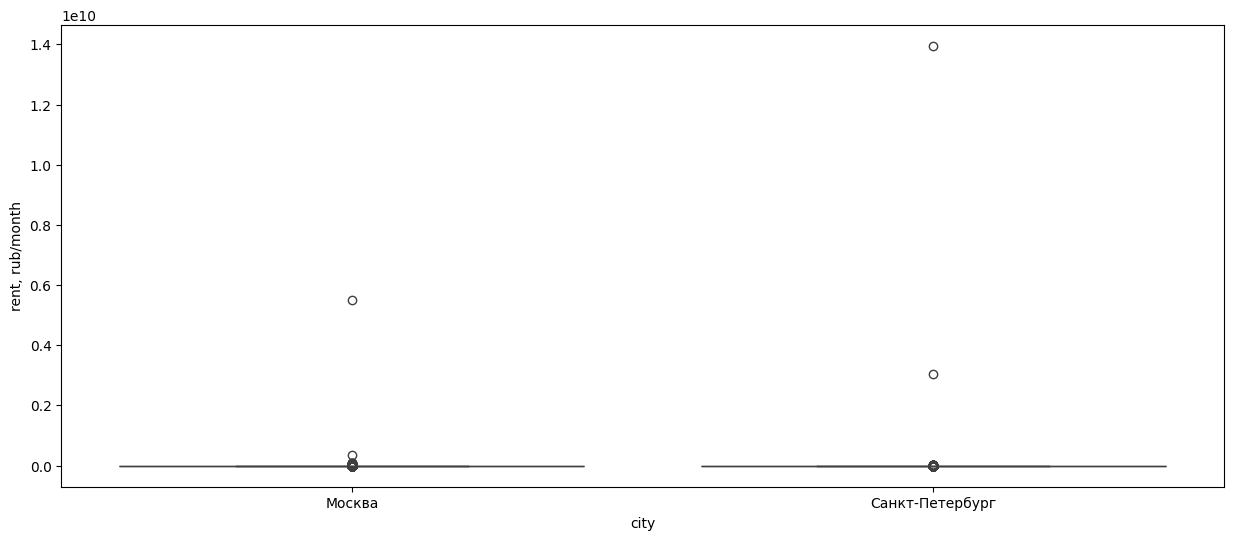

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_rent, x='city', y='rent, rub/month')

<Axes: xlabel='city', ylabel='square, m^2'>

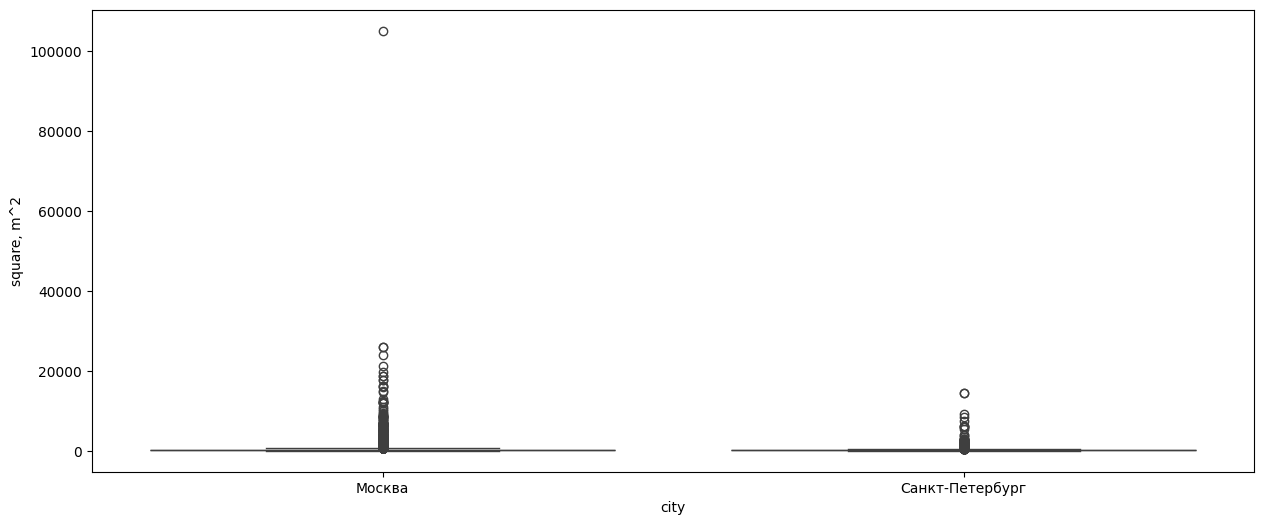

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_rent, x='city', y='square, m^2')

boxplot практически невозможно разглядеть, можем заметить, что есть огромные выбросы - огромные цены на аренду. Например, в Санкт-Петербурге есть площадь с ценой около 1400000 рублей в месяц.
Клиент открывает первый бизнес и не готов вкладывать огромные сбережения, поэтому отбросим огромные цены - выбросы с помощью самого популярного способа удалять выбросы:

- Ниже первой квартили - `3 iqr` (межквартильное расстояние)
- Выше третьей квартили + `3 iqr` (межквартильное расстояние)

Аналогично для первого бизнеса тяжело обустраивать и содержать огромные помещения (идут расходы на мебель, коммунальные услуги, обеспечение, ремонт и т. п.), поэтому уберем выбросы с большими площадями, но поменяем константу на 5

In [ ]:
Q1_rent = df_rent['rent, rub/month'].describe()['25%']
Q3_rent = df_rent['rent, rub/month'].describe()['75%']
Q1_S = df_rent['square, m^2'].describe()['25%']
Q3_S = df_rent['square, m^2'].describe()['75%']

IQR_rent = Q3_rent - Q1_rent
IQR_S = Q3_S - Q1_S

In [ ]:
df_rent = df_rent[(df_rent['rent, rub/month'] < (Q3_rent + 3 * IQR_rent)) & (df_rent['square, m^2'] < (Q3_S + 5 * IQR_S))] # минимальные значения не убираем, т. к. нам выгодно мало тратить

In [ ]:
df_rent.describe()

,"rent, rub/month","price_per_sqm, rub/month","square, m^2",lat,lon,distance_km
count,8.721000e+03,8721.000000,8721.000000,8032.000000,8032.000000,8032.000000
mean,5.006689e+05,4029.662539,167.242633,56.574479,36.143068,1.170709
std,5.094575e+05,3984.732924,187.667470,1.675203,2.903842,2.412228
min,1.400000e+02,1.000000,1.000000,55.172889,29.730048,0.007069
25%,1.550000e+05,1891.000000,55.000000,55.709426,37.410385,0.329693
50%,3.000000e+05,2917.000000,100.000000,55.771126,37.565240,0.614273
75%,6.500000e+05,4605.000000,200.000000,55.863964,37.640300,1.036542
max,2.674325e+06,57142.000000,1200.000000,60.213256,37.946323,47.593815


Между третьим квантилем и максимумом все еще большой разброс, который указывает, что есть выбросы

<Axes: xlabel='city', ylabel='rent, rub/month'>

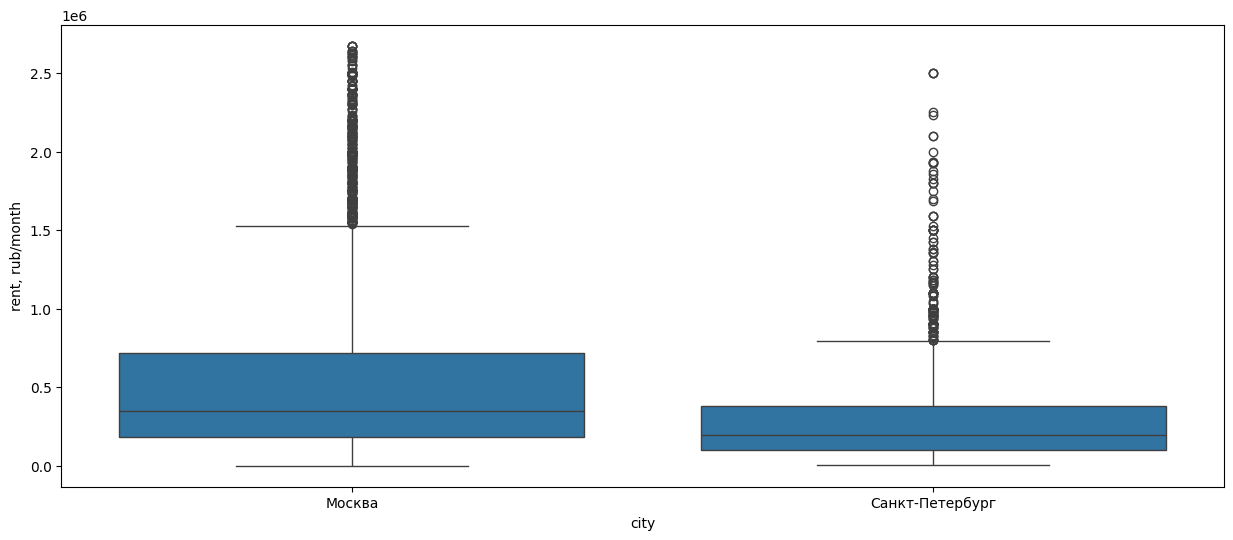

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_rent, x='city', y='rent, rub/month')

Теперь выбросов с низкой ценой за m^2 нет, но есть много выбросов с высокой ценой. В таком случае тратитиься на аренду данных помещений не целесообазно для нашего клиента, поэтому в дальнейшем анализе мы не будем их рассматривать.

<Axes: xlabel='city', ylabel='square, m^2'>

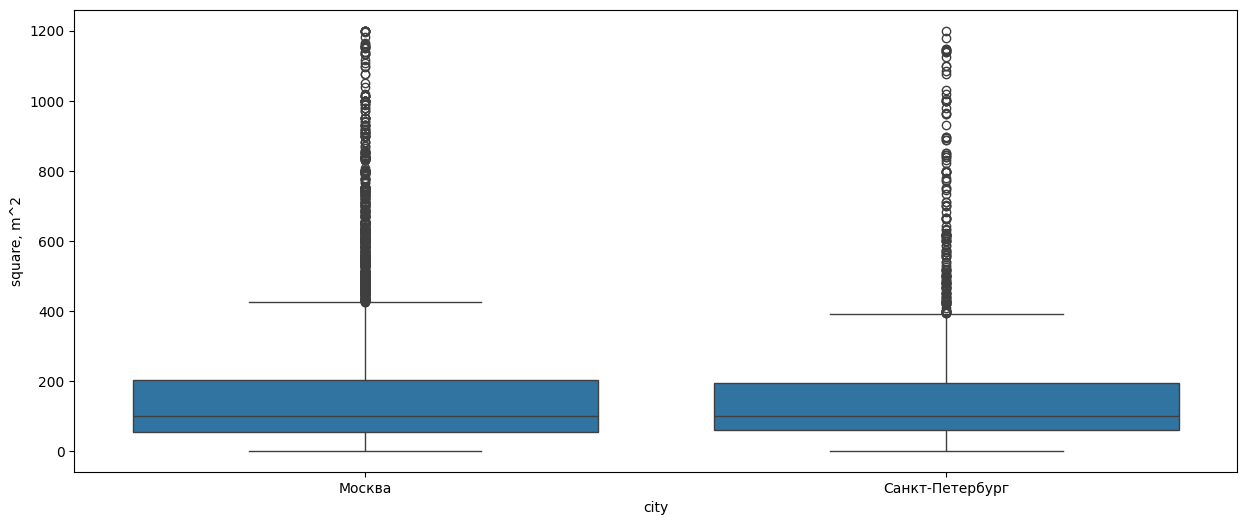

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_rent, x='city', y='square, m^2')

Теперь выбросов с маленькой площадью нет, но есть много выбросов с большой площадью. Данные помещения неудобны для открытия первой точки, поэтому далее мы не будем их рассматривать.

Удалим строки, в которых есть пропуски в значениях координат

In [ ]:
df_rent.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8721 entries, 0 to 9426
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rent, rub/month           8721 non-null   int64  
 1   address                   8721 non-null   object 
 2   city                      8721 non-null   object 
 3   price_per_sqm, rub/month  8721 non-null   int64  
 4   square, m^2               8721 non-null   int64  
 5   type                      8721 non-null   object 
 6   url                       8721 non-null   object 
 7   OSM_address               8721 non-null   object 
 8   address_info              8721 non-null   object 
 9   district                  8050 non-null   object 
 10  lat                       8032 non-null   float64
 11  lon                       8032 non-null   float64
 12  nearest_metro             8032 non-null   object 
 13  distance_km               8032 non-null   float64
dtypes: float64(3)

In [ ]:
df_rent= df_rent.dropna(subset=['lat', 'lon'])

In [ ]:
df_rent = df_rent[((df_rent['lon'] >= 37.3) & (df_rent['lon'] <= 37.95) & (df_rent['lat'] >= 55.55) & (df_rent['lat'] <= 55.95)) |
        ((df_rent['lon'] >= 30.1) & (df_rent['lon'] <= 30.5) & (df_rent['lat'] >= 59.8) & (df_rent['lat'] <= 60.1))]

Ограничили координатами города наши помещения, потому что есть помещения, которые могли случайно попасть в даатсет при сборе данных.

Координаты центров Москвы и Санкт-Петербурга

In [ ]:
MOSCOW_CENTER = [55.751244, 37.618423]
SPB_CENTER = [59.937500, 30.308611]

Рассмотрим часть датасета для Москвы и рассчитаем расстояние от помещения до центра в каждом городе

In [ ]:
df_rent_Moscow = df_rent[df_rent['city'] == "Москва"]
df_rent_Moscow

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km
0,1500000,Пречистенка,Москва,13636,110,Универсальное помещение,https://msk.n1.ru/view/114210381/?open_card_kn,"Пречистенка, 19/11 ст2, Москва, Россия","{'district': 'район Хамовники', 'lat': 55.7430...",район Хамовники,55.743015,37.596967,"Москва, Кропоткинская",0.498615
1,1197919,Таежная,Москва,1917,625,Универсальное помещение,https://msk.n1.ru/view/115999047/?open_card_kn,"Таежная, 1, Москва, Россия","{'district': 'Лосиноостровский район', 'lat': ...",Лосиноостровский район,55.881107,37.700736,"Москва, Медведково",2.532474
3,386458,Шумкина,Москва,1459,265,Универсальное помещение,https://msk.n1.ru/view/116011103/?open_card_kn,"Шумкина, 20 ст1, Москва, Россия","{'district': 'район Сокольники', 'lat': 55.789...",район Сокольники,55.789422,37.666981,"Москва, Митьково",0.481996
4,68125,Шумкина,Москва,2084,32,Универсальное помещение,https://msk.n1.ru/view/115777113/?open_card_kn,"Шумкина, 20 ст1, Москва, Россия","{'district': 'район Сокольники', 'lat': 55.789...",район Сокольники,55.789422,37.666981,"Москва, Митьково",0.481996
5,320100,Павелецкий 2-й проезд,Москва,3000,106,Универсальное помещение,https://msk.n1.ru/view/115502574/?open_card_kn,"Павелецкий 2-й проезд, 5 ст1, Москва, Россия","{'district': 'Даниловский район', 'lat': 55.71...",Даниловский район,55.713212,37.643493,"Москва, Автозаводская",1.111425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,1500000,Краснопролетарская,Москва,3968,378,Помещение под бар/ресторан,https://msk.n1.ru/view/109731158/?open_card_kn,"Краснопролетарская, 36, Москва, Россия","{'district': 'Тверской район', 'lat': 55.77991...",Тверской район,55.779914,37.605748,"Москва, Новослободская",0.131475
7693,1176000,Пресненская набережная,Москва,6461,182,Помещение под бар/ресторан,https://msk.n1.ru/view/111002230/?open_card_kn,"Пресненская набережная, 10с, Москва, Россия","{'district': 'Пресненский район', 'lat': 55.74...",Пресненский район,55.748846,37.535373,"Москва, Москва-Сити",0.115122
7694,2000000,Пресненская набережная,Москва,4819,415,Помещение под бар/ресторан,https://msk.n1.ru/view/109683444/?open_card_kn,"Пресненская набережная, 10 ст2, Москва, Россия","{'district': 'Пресненский район', 'lat': 55.74...",Пресненский район,55.745670,37.536463,"Москва, Москва-Сити",0.328991
7695,300003,Братиславская,Москва,2041,147,Помещение под бар/ресторан,https://msk.n1.ru/view/112349375/?open_card_kn,"Братиславская, 18 корп. 1, Москва, Россия","{'district': 'район Марьино', 'lat': 55.655882...",район Марьино,55.655882,37.763084,"Москва, Братиславская",0.889544


In [ ]:
from geopy.distance import geodesic #библиотека для нахождения расстояния по координатам

In [ ]:
df_rent_Moscow['distance_center_km'] = df_rent_Moscow.apply(lambda row: geodesic((row['lat'], row['lon']), MOSCOW_CENTER).km, axis=1).round(2)
df_rent_Moscow['distance_center_m'] = (df_rent_Moscow['distance_center_km'] * 1000).astype(int)

/tmp/ipython-input-2816000380.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rent_Moscow['distance_center_km'] = df_rent_Moscow.apply(lambda row: geodesic((row['lat'], row['lon']), MOSCOW_CENTER).km, axis=1).round(2)
/tmp/ipython-input-2816000380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rent_Moscow['distance_center_m'] = (df_rent_Moscow['distance_center_km'] * 1000).astype(int)


In [ ]:
df_rent_Moscow

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km,distance_center_km,distance_center_m
0,1500000,Пречистенка,Москва,13636,110,Универсальное помещение,https://msk.n1.ru/view/114210381/?open_card_kn,"Пречистенка, 19/11 ст2, Москва, Россия","{'district': 'район Хамовники', 'lat': 55.7430...",район Хамовники,55.743015,37.596967,"Москва, Кропоткинская",0.498615,1.63,1630
1,1197919,Таежная,Москва,1917,625,Универсальное помещение,https://msk.n1.ru/view/115999047/?open_card_kn,"Таежная, 1, Москва, Россия","{'district': 'Лосиноостровский район', 'lat': ...",Лосиноостровский район,55.881107,37.700736,"Москва, Медведково",2.532474,15.35,15350
3,386458,Шумкина,Москва,1459,265,Универсальное помещение,https://msk.n1.ru/view/116011103/?open_card_kn,"Шумкина, 20 ст1, Москва, Россия","{'district': 'район Сокольники', 'lat': 55.789...",район Сокольники,55.789422,37.666981,"Москва, Митьково",0.481996,5.23,5230
4,68125,Шумкина,Москва,2084,32,Универсальное помещение,https://msk.n1.ru/view/115777113/?open_card_kn,"Шумкина, 20 ст1, Москва, Россия","{'district': 'район Сокольники', 'lat': 55.789...",район Сокольники,55.789422,37.666981,"Москва, Митьково",0.481996,5.23,5230
5,320100,Павелецкий 2-й проезд,Москва,3000,106,Универсальное помещение,https://msk.n1.ru/view/115502574/?open_card_kn,"Павелецкий 2-й проезд, 5 ст1, Москва, Россия","{'district': 'Даниловский район', 'lat': 55.71...",Даниловский район,55.713212,37.643493,"Москва, Автозаводская",1.111425,4.52,4520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,1500000,Краснопролетарская,Москва,3968,378,Помещение под бар/ресторан,https://msk.n1.ru/view/109731158/?open_card_kn,"Краснопролетарская, 36, Москва, Россия","{'district': 'Тверской район', 'lat': 55.77991...",Тверской район,55.779914,37.605748,"Москва, Новослободская",0.131475,3.29,3290
7693,1176000,Пресненская набережная,Москва,6461,182,Помещение под бар/ресторан,https://msk.n1.ru/view/111002230/?open_card_kn,"Пресненская набережная, 10с, Москва, Россия","{'district': 'Пресненский район', 'lat': 55.74...",Пресненский район,55.748846,37.535373,"Москва, Москва-Сити",0.115122,5.22,5220
7694,2000000,Пресненская набережная,Москва,4819,415,Помещение под бар/ресторан,https://msk.n1.ru/view/109683444/?open_card_kn,"Пресненская набережная, 10 ст2, Москва, Россия","{'district': 'Пресненский район', 'lat': 55.74...",Пресненский район,55.745670,37.536463,"Москва, Москва-Сити",0.328991,5.18,5180
7695,300003,Братиславская,Москва,2041,147,Помещение под бар/ресторан,https://msk.n1.ru/view/112349375/?open_card_kn,"Братиславская, 18 корп. 1, Москва, Россия","{'district': 'район Марьино', 'lat': 55.655882...",район Марьино,55.655882,37.763084,"Москва, Братиславская",0.889544,13.98,13980


Сделаем то же самое для Санкт-Петербурга

In [ ]:
df_rent_SPB = df_rent[df_rent['city'] == "Санкт-Петербург"]
df_rent_SPB

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km
7697,200000,Тосина,Санкт-Петербург,2361,84,Универсальное помещение,https://spb.n1.ru/view/115905928/?open_card_kn,"Тосина, 1 корп. 2, Санкт-Петербург, Россия","{'district': 'округ Волковское', 'lat': 59.902...",округ Волковское,59.902662,30.349236,"Санкт-Петербург, Волковская",0.879784
7698,330000,Заставская,Санкт-Петербург,6600,50,Универсальное помещение,https://spb.n1.ru/view/115285927/?open_card_kn,"Заставская, 30, Санкт-Петербург, Россия","{'district': 'округ Московская застава', 'lat'...",округ Московская застава,59.887331,30.343781,"Санкт-Петербург, Волковская",1.249201
7700,490000,Науки проспект,Санкт-Петербург,8750,56,Универсальное помещение,https://spb.n1.ru/view/115986821/?open_card_kn,"Науки проспект, 23 корп. 2, Санкт-Петербург, Р...","{'district': 'округ Пискарёвка', 'lat': 60.003...",округ Пискарёвка,60.003741,30.435211,"Санкт-Петербург, Академическая",2.414211
7702,31500,Индустриальный проспект,Санкт-Петербург,750,42,Универсальное помещение,https://spb.n1.ru/view/115970363/?open_card_kn,"Индустриальный проспект, 11, Санкт-Петербург, ...","{'district': 'округ Пороховые', 'lat': 59.9384...",округ Пороховые,59.938465,30.477283,"Санкт-Петербург, Проспект Большевиков",2.159403
7703,350000,Маяковского,Санкт-Петербург,5833,60,Универсальное помещение,https://spb.n1.ru/view/115613437/?open_card_kn,"Маяковского, 3, Санкт-Петербург, Россия","{'district': 'Литейный округ', 'lat': 59.93398...",Литейный округ,59.933980,30.355041,"Санкт-Петербург, Маяковская",0.265216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9421,108000,Ветеранов проспект,Санкт-Петербург,1200,90,Помещение под бар/ресторан,https://spb.n1.ru/view/115659006/?open_card_kn,"Ветеранов проспект, 133 корп. 1, Санкт-Петербу...","{'district': 'округ Ульянка', 'lat': 59.833541...",округ Ульянка,59.833542,30.217482,"Санкт-Петербург, Проспект Ветеранов",2.115935
9422,139000,Московский проспект,Санкт-Петербург,2249,61,Помещение под бар/ресторан,https://spb.n1.ru/view/106961445/?open_card_kn,"Московский проспект, 72 корп. 2, Санкт-Петербу...","{'district': 'округ Измайловское', 'lat': 59.9...",округ Измайловское,59.902811,30.318498,"Санкт-Петербург, Фрунзенская (закрыта)",0.383607
9423,961538,Энергетиков проспект,Санкт-Петербург,3083,311,Помещение под бар/ресторан,https://spb.n1.ru/view/110365219/?open_card_kn,"Энергетиков проспект, 6, Санкт-Петербург, Россия","{'district': 'округ Большая Охта', 'lat': 59.9...",округ Большая Охта,59.955832,30.432095,"Санкт-Петербург, Ладожская",2.639591
9424,110000,Заозерная,Санкт-Петербург,2444,45,Помещение под бар/ресторан,https://spb.n1.ru/view/112083708/?open_card_kn,"Заозерная, 3 корп. 3, Санкт-Петербург, Россия","{'district': 'округ Московская застава', 'lat'...",округ Московская застава,59.906229,30.324407,"Санкт-Петербург, Фрунзенская (закрыта)",0.377055


In [ ]:
df_rent_SPB['distance_center_km'] = df_rent_SPB.apply(lambda row: geodesic((row['lat'], row['lon']), SPB_CENTER).km, axis=1).round(2)
df_rent_SPB['distance_center_m'] = (df_rent_SPB['distance_center_km'] * 1000).astype(int)

/tmp/ipython-input-2257360096.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rent_SPB['distance_center_km'] = df_rent_SPB.apply(lambda row: geodesic((row['lat'], row['lon']), SPB_CENTER).km, axis=1).round(2)
/tmp/ipython-input-2257360096.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rent_SPB['distance_center_m'] = (df_rent_SPB['distance_center_km'] * 1000).astype(int)


In [ ]:
df_rent_SPB

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km,distance_center_km,distance_center_m
7697,200000,Тосина,Санкт-Петербург,2361,84,Универсальное помещение,https://spb.n1.ru/view/115905928/?open_card_kn,"Тосина, 1 корп. 2, Санкт-Петербург, Россия","{'district': 'округ Волковское', 'lat': 59.902...",округ Волковское,59.902662,30.349236,"Санкт-Петербург, Волковская",0.879784,4.50,4500
7698,330000,Заставская,Санкт-Петербург,6600,50,Универсальное помещение,https://spb.n1.ru/view/115285927/?open_card_kn,"Заставская, 30, Санкт-Петербург, Россия","{'district': 'округ Московская застава', 'lat'...",округ Московская застава,59.887331,30.343781,"Санкт-Петербург, Волковская",1.249201,5.93,5930
7700,490000,Науки проспект,Санкт-Петербург,8750,56,Универсальное помещение,https://spb.n1.ru/view/115986821/?open_card_kn,"Науки проспект, 23 корп. 2, Санкт-Петербург, Р...","{'district': 'округ Пискарёвка', 'lat': 60.003...",округ Пискарёвка,60.003741,30.435211,"Санкт-Петербург, Академическая",2.414211,10.22,10220
7702,31500,Индустриальный проспект,Санкт-Петербург,750,42,Универсальное помещение,https://spb.n1.ru/view/115970363/?open_card_kn,"Индустриальный проспект, 11, Санкт-Петербург, ...","{'district': 'округ Пороховые', 'lat': 59.9384...",округ Пороховые,59.938465,30.477283,"Санкт-Петербург, Проспект Большевиков",2.159403,9.43,9430
7703,350000,Маяковского,Санкт-Петербург,5833,60,Универсальное помещение,https://spb.n1.ru/view/115613437/?open_card_kn,"Маяковского, 3, Санкт-Петербург, Россия","{'district': 'Литейный округ', 'lat': 59.93398...",Литейный округ,59.933980,30.355041,"Санкт-Петербург, Маяковская",0.265216,2.63,2630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9421,108000,Ветеранов проспект,Санкт-Петербург,1200,90,Помещение под бар/ресторан,https://spb.n1.ru/view/115659006/?open_card_kn,"Ветеранов проспект, 133 корп. 1, Санкт-Петербу...","{'district': 'округ Ульянка', 'lat': 59.833541...",округ Ульянка,59.833542,30.217482,"Санкт-Петербург, Проспект Ветеранов",2.115935,12.66,12660
9422,139000,Московский проспект,Санкт-Петербург,2249,61,Помещение под бар/ресторан,https://spb.n1.ru/view/106961445/?open_card_kn,"Московский проспект, 72 корп. 2, Санкт-Петербу...","{'district': 'округ Измайловское', 'lat': 59.9...",округ Измайловское,59.902811,30.318498,"Санкт-Петербург, Фрунзенская (закрыта)",0.383607,3.90,3900
9423,961538,Энергетиков проспект,Санкт-Петербург,3083,311,Помещение под бар/ресторан,https://spb.n1.ru/view/110365219/?open_card_kn,"Энергетиков проспект, 6, Санкт-Петербург, Россия","{'district': 'округ Большая Охта', 'lat': 59.9...",округ Большая Охта,59.955832,30.432095,"Санкт-Петербург, Ладожская",2.639591,7.20,7200
9424,110000,Заозерная,Санкт-Петербург,2444,45,Помещение под бар/ресторан,https://spb.n1.ru/view/112083708/?open_card_kn,"Заозерная, 3 корп. 3, Санкт-Петербург, Россия","{'district': 'округ Московская застава', 'lat'...",округ Московская застава,59.906229,30.324407,"Санкт-Петербург, Фрунзенская (закрыта)",0.377055,3.59,3590


In [ ]:
df_rent= pd.concat([df_rent_SPB, df_rent_Moscow], ignore_index=True)
df_rent

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km,distance_center_km,distance_center_m
0,200000,Тосина,Санкт-Петербург,2361,84,Универсальное помещение,https://spb.n1.ru/view/115905928/?open_card_kn,"Тосина, 1 корп. 2, Санкт-Петербург, Россия","{'district': 'округ Волковское', 'lat': 59.902...",округ Волковское,59.902662,30.349236,"Санкт-Петербург, Волковская",0.879784,4.50,4500
1,330000,Заставская,Санкт-Петербург,6600,50,Универсальное помещение,https://spb.n1.ru/view/115285927/?open_card_kn,"Заставская, 30, Санкт-Петербург, Россия","{'district': 'округ Московская застава', 'lat'...",округ Московская застава,59.887331,30.343781,"Санкт-Петербург, Волковская",1.249201,5.93,5930
2,490000,Науки проспект,Санкт-Петербург,8750,56,Универсальное помещение,https://spb.n1.ru/view/115986821/?open_card_kn,"Науки проспект, 23 корп. 2, Санкт-Петербург, Р...","{'district': 'округ Пискарёвка', 'lat': 60.003...",округ Пискарёвка,60.003741,30.435211,"Санкт-Петербург, Академическая",2.414211,10.22,10220
3,31500,Индустриальный проспект,Санкт-Петербург,750,42,Универсальное помещение,https://spb.n1.ru/view/115970363/?open_card_kn,"Индустриальный проспект, 11, Санкт-Петербург, ...","{'district': 'округ Пороховые', 'lat': 59.9384...",округ Пороховые,59.938465,30.477283,"Санкт-Петербург, Проспект Большевиков",2.159403,9.43,9430
4,350000,Маяковского,Санкт-Петербург,5833,60,Универсальное помещение,https://spb.n1.ru/view/115613437/?open_card_kn,"Маяковского, 3, Санкт-Петербург, Россия","{'district': 'Литейный округ', 'lat': 59.93398...",Литейный округ,59.933980,30.355041,"Санкт-Петербург, Маяковская",0.265216,2.63,2630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7644,1500000,Краснопролетарская,Москва,3968,378,Помещение под бар/ресторан,https://msk.n1.ru/view/109731158/?open_card_kn,"Краснопролетарская, 36, Москва, Россия","{'district': 'Тверской район', 'lat': 55.77991...",Тверской район,55.779914,37.605748,"Москва, Новослободская",0.131475,3.29,3290
7645,1176000,Пресненская набережная,Москва,6461,182,Помещение под бар/ресторан,https://msk.n1.ru/view/111002230/?open_card_kn,"Пресненская набережная, 10с, Москва, Россия","{'district': 'Пресненский район', 'lat': 55.74...",Пресненский район,55.748846,37.535373,"Москва, Москва-Сити",0.115122,5.22,5220
7646,2000000,Пресненская набережная,Москва,4819,415,Помещение под бар/ресторан,https://msk.n1.ru/view/109683444/?open_card_kn,"Пресненская набережная, 10 ст2, Москва, Россия","{'district': 'Пресненский район', 'lat': 55.74...",Пресненский район,55.745670,37.536463,"Москва, Москва-Сити",0.328991,5.18,5180
7647,300003,Братиславская,Москва,2041,147,Помещение под бар/ресторан,https://msk.n1.ru/view/112349375/?open_card_kn,"Братиславская, 18 корп. 1, Москва, Россия","{'district': 'район Марьино', 'lat': 55.655882...",район Марьино,55.655882,37.763084,"Москва, Братиславская",0.889544,13.98,13980


## Второй датасет bars - чистка данных

In [ ]:
import pandas as pd

In [ ]:
#uploaded = files.upload()

In [ ]:
df_bars = pd.read_csv("bars_top_cities.csv")

In [ ]:
df_bars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 31 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   address_name                             2227 non-null   object 
 1   attribute_groups                         2200 non-null   object 
 2   full_name                                91 non-null     object 
 3   id                                       2237 non-null   int64  
 4   name                                     2237 non-null   object 
 5   purpose_name                             91 non-null     object 
 6   rubrics                                  2237 non-null   object 
 7   type                                     2237 non-null   object 
 8   attributes                               2237 non-null   object 
 9   address.building_id                      2237 non-null   int64  
 10  address.components                       2237 no

In [ ]:
df_bars['attributes']

,attributes
0,[]
1,[]
2,[]
3,[]
4,[]
...,...
2232,[]
2233,['Чек 1400\xa0₽']
2234,[]
2235,[]


In [ ]:
df_bars['attributes'] = df_bars['attributes'].astype(str)
df_bars['attributes'] = (
    df_bars ['attributes']
    .str.replace(r"[\[\]']", "", regex=True)
    .str.extract(r'(\d+)')
    .astype(float)
)

df_bars['attributes'] = df_bars['attributes'].replace('', np.nan)

In [ ]:
df_bars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 31 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   address_name                             2227 non-null   object 
 1   attribute_groups                         2200 non-null   object 
 2   full_name                                91 non-null     object 
 3   id                                       2237 non-null   int64  
 4   name                                     2237 non-null   object 
 5   purpose_name                             91 non-null     object 
 6   rubrics                                  2237 non-null   object 
 7   type                                     2237 non-null   object 
 8   attributes                               1238 non-null   float64
 9   address.building_id                      2237 non-null   int64  
 10  address.components                       2237 no

Датасет bars содержит данные о барах в 7 городах-миллиониках

**Описание признаков:**
* `address_name ` - адрес бара (улица, дом, строение)
* `attribute_groups ` - аирибуты заведения
* `full_name` - полное официальное юридическое название с указанием адреса
* `id` - уникальный код бара на 2ГИС
* `name` - название бара
* `purpose_name` - целевой бизнес завидения (например, ресторан)
* `rubrics` - категории заведения
* `type` - тип точки сети (branch-филиал)
* `attributes` - средний чек заведения
* `address.building_id` - айди здания на 2ГИС
* `address.components` - "разобранный" адрес (номер дома, улица и т. д.)
* `address.postcode` - почтовый индекс
* `point.lat` - широта
* `point.lon` - долгота
* `reviews.general_rating` - средний рейтинг заведения (максимум 5.0)
* `reviews.general_review_count` - общее количество текстовых отзывов
* `reviews.general_review_count_with_stars` - общее количество отзывов с выставленными оценками
* `reviews.is_reviewable` - можно ли оставить отзыв
* `reviews.is_reviewable_on_flamp` - можно ли оставить отзыв на flamp - помощник 2ГИС
* `reviews.items` - общая сводка данных об отзывах
* `reviews.org_rating` - средний рейтинг организации - всей сети (максимум 5.0)
* `reviews.org_review_count` - бщее количество текстовых отзывов у оргнизации - всей сети
* `reviews.org_review_count_with_stars` - общее количество отзывов с выставленными оценками организации - всей сети
* `address.landmark_name` - ориентир (жк, парк, рынок и т. п.)
* `address_comment` - комментарий к адресу (этаж, дополнительные ориентиры)
* `address.building_name` - название здания (тц, трк, жк и т. п.)
* `reviews.rating` - средний рейтинг, собранных за последние n дней (как правило, n равно 1) для обновления рейтинга
* `reviews.review_count` - количество, собранных за последние n дней (как правило, n равно 1) для обновления количества оценок
* `reviews.recommendation_count` - количество рекомендаций организации
* `building_name` - название здания-бара, если здание полностью является заведением
* `city` - город, в котором находится бар




Рассмотрим пропуски

In [ ]:
df_bars.isna().sum()

,0
address_name,10
attribute_groups,37
full_name,2146
id,0
name,0
purpose_name,2146
rubrics,0
type,0
attributes,999
address.building_id,0


Есть столбцы с огромным количеством пропусков, посмотрим пропуски в процентном соотношении

In [ ]:
df_miss = (df_bars.isna().sum()/len(df_bars)) * 100
df_miss = df_miss.rename('missing_percentage')
df_miss

,missing_percentage
address_name,0.447027
attribute_groups,1.654001
full_name,95.932052
id,0.000000
name,0.000000
purpose_name,95.932052
rubrics,0.000000
type,0.000000
attributes,44.658024
address.building_id,0.000000


Большинство столбцов с большим количеством пропуском либо являются дополнительной информацией, которая может иметься не у всех заведений, либо это полная юридическая информация, которую редко прописывают на поисковых картах

Если у признака больше 50% пропусков, то удаляем его, он не так информативен и ничем нам не поможет. Удалим эти столбцы

In [ ]:
df_bars = df_bars.drop(columns=list((df_miss[df_miss >= 50]).index))

In [ ]:
df_bars

,address_name,attribute_groups,id,name,rubrics,type,attributes,address.building_id,address.components,address.postcode,...,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city
0,"деревня Сосенки, 150","[{'attributes': [{'id': '70000201006748017', '...",70000001020034740,"New Moscow, ресторан","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",branch,NaN,4504235306854603,"[{'number': '150', 'street': 'деревня Сосенки'...",108802.0,...,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва
1,"Куприна проспект, 18 к2","[{'attributes': [{'id': '70000201006747996', '...",70000001106158750,"Z.a.m.i.n, гастролаундж-бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",branch,NaN,70030076326225294,"[{'number': '18 к2', 'street': 'Куприна проспе...",108826.0,...,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва
2,"улица Эдварда Грига, 15","[{'attributes': [{'id': '70000201006756678', '...",70000001097044775,"Слеза комсомолки, рюмочная","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",branch,NaN,70030076190387677,"[{'number': '15', 'street': 'улица Эдварда Гри...",108834.0,...,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва
3,"Скандинавский бульвар, 19","[{'attributes': [{'id': '70000201006756678', '...",70000001085797627,"Rich man celebrity, лаундж-бар","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",branch,NaN,70030076199558084,"[{'number': '19', 'street': 'Скандинавский бул...",108834.0,...,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва
4,"Скандинавский бульвар, 12","[{'attributes': [{'id': '70000201006756774', '...",70000001096460413,"The Beer, крафтовый бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",branch,NaN,70030076177876871,"[{'number': '12', 'street': 'Скандинавский бул...",108801.0,...,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,"улица Фёдора Абрамова, 8а","[{'attributes': [{'id': '70000201006748734', '...",70000001032668177,"Abramov, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",branch,NaN,5348660212819133,"[{'number': '8а', 'street': 'улица Фёдора Абра...",194363.0,...,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург
2233,"улица Фёдора Абрамова, 8","[{'attributes': [{'id': '70000201006747423', '...",70000001026845553,"Pur pur, кафе-бар","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",branch,1400.0,5348660212819133,"[{'number': '8', 'street': 'улица Фёдора Абрам...",194363.0,...,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург
2234,"Ручьёвский проспект, 5","[{'attributes': [{'id': '70000201006756774', '...",70000001102807396,"Crazy, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",branch,NaN,70030076849412007,"[{'number': '5', 'street': 'Ручьёвский проспек...",188677.0,...,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург
2235,"Ручьёвский проспект, 15","[{'attributes': [{'id': '70000201006750805', '...",70000001093765382,"У Гриба, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",branch,NaN,70030076252005470,"[{'number': '15', 'street': 'Ручьёвский проспе...",188687.0,...,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург


1. Рассмотрим пропуски в колонке address_name

Удаляем строчки с пустыми значениями в колонке `address_name`. Нам важны адреса для дальнейшего анализа, потому что мы хотим выявить районы и сориентировать клиента по выгодному и хорошему месту открытия бара.

In [ ]:
df_bars = df_bars.dropna(subset=['address_name'])

2.

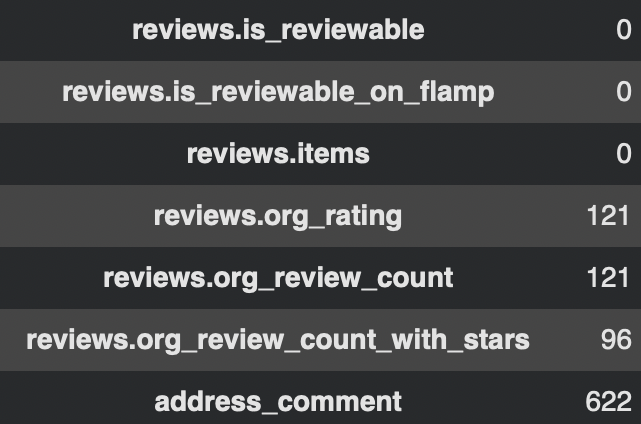*рейтинги*...?

Удаляем колонки из таблички выше, кроме `reviews.org.rating`.

- `reviews.is_reviewable`: значение этого столбца не дает нам информации для анализа территории и района
- `reviews.is_reviewable_on_flamp`: значение этого столбца не дает нам информации для анализа территории и района
- `reviews.items`: в этом столбце находится та же информация, что и в столбцах, описанных выше
- `reviews.org_review_count`: значение этого столбца не дает нам информации для анализа территории и района
- `reviews.org_review_count_with_stars`: значение этого столбца не дает нам информации для анализа территории и района
- `	address.components`:  значение этого столбца не дает нам информации для анализа территории и района
- `attribute_groups`: значения этого столбца не дает нам информации, необходмой для анализа

In [ ]:
df_bars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2227 entries, 0 to 2236
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   address_name                             2227 non-null   object 
 1   attribute_groups                         2191 non-null   object 
 2   id                                       2227 non-null   int64  
 3   name                                     2227 non-null   object 
 4   rubrics                                  2227 non-null   object 
 5   type                                     2227 non-null   object 
 6   attributes                               1236 non-null   float64
 7   address.building_id                      2227 non-null   int64  
 8   address.components                       2227 non-null   object 
 9   address.postcode                         2226 non-null   float64
 10  point.lat                                2227 non-nul

In [ ]:
df_bars = df_bars.drop(columns=['attribute_groups', ])

3. address_comment имеет много пропусков и дополняет информацию о местоположении бара. Например, этаж, где вход и т. п. Эта информация не поможет нам в анализе, поэтому удалим.

4. Также нам не нужны айди с 2ГИС, потому что это внутренняя работа 2ГИС.

5. type показывает только одно значение - branch. Признак не репрезентативный

In [ ]:
df_bars = df_bars.drop(columns=['id', 'type', 'address.building_id', 'address.components'])

In [ ]:
df_bars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2227 entries, 0 to 2236
Data columns (total 18 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   address_name                             2227 non-null   object 
 1   name                                     2227 non-null   object 
 2   rubrics                                  2227 non-null   object 
 3   attributes                               1236 non-null   float64
 4   address.postcode                         2226 non-null   float64
 5   point.lat                                2227 non-null   float64
 6   point.lon                                2227 non-null   float64
 7   reviews.general_rating                   2094 non-null   float64
 8   reviews.general_review_count             2094 non-null   float64
 9   reviews.general_review_count_with_stars  2133 non-null   float64
 10  reviews.is_reviewable                    2227 non-nul

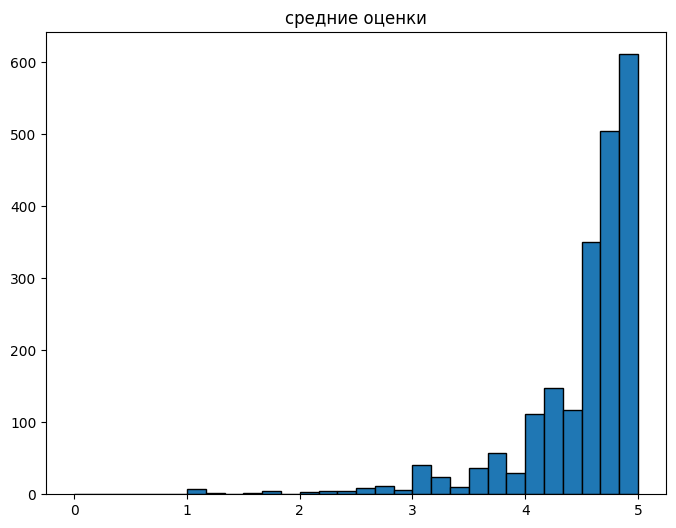

In [ ]:
figsize(8, 6)

plt.hist(df_bars['reviews.general_rating'], bins = 30, edgecolor='k')

plt.title('средние оценки')
plt.show()

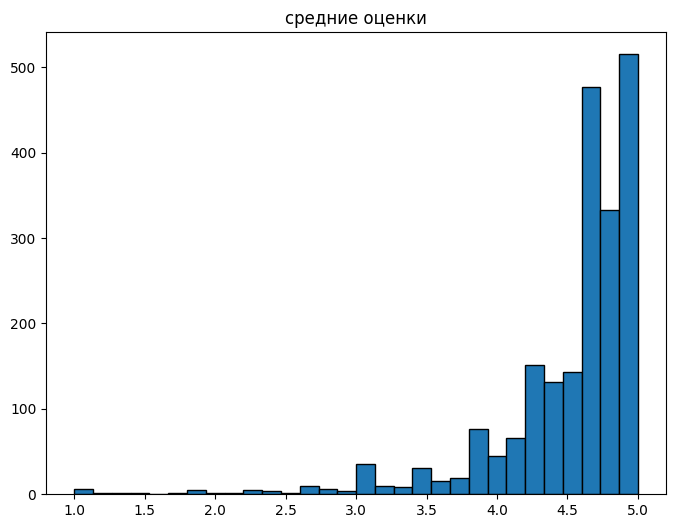

In [ ]:
figsize(8, 6)

plt.hist(df_bars['reviews.org_rating'], bins = 30, edgecolor='k')

plt.title('средние оценки')
plt.show()

In [ ]:
df_bars['reviews.general_rating'].corr(df_bars['reviews.org_rating'])

np.float64(0.9280042787001856)

In [ ]:
abs(df_bars['reviews.general_rating'] - (df_bars['reviews.org_rating'])).mean()

np.float64(0.0645176695319962)

In [ ]:
len(df_bars[df_bars['reviews.general_rating'].isnull()]) - len(df_bars[df_bars['reviews.general_rating'].isnull() & df_bars['reviews.org_rating'].isnull()])

11

Рассмотрим корреляцию столбца `reviews.general_rating` и `reviews.org_rating`, она равняется 0,94. Данная корреляция высокая, сильно положительная, что показывает сильную линейную зависимость данных признаков. Из чего мы можем сделать вывод, что мы можем заполнить значение 8 ячеек, у которых отсутсвует занчение в `reviews.general_rating`, значениями из столбца `reviews.org_rating`

In [ ]:
df_bars['reviews.general_rating'] = df_bars['reviews.general_rating'].fillna(df_bars['reviews.org_rating'])

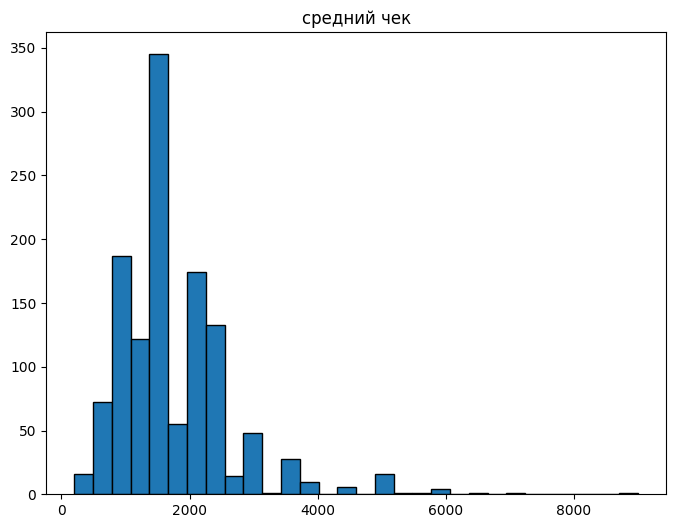

In [ ]:
figsize(8, 6)

plt.hist(df_bars['attributes'], bins = 30, edgecolor='k')

plt.title('средний чек')
plt.show()

In [ ]:
df_bars_Moscow = df_bars[df_bars['city'] == "Москва"]
df_bars_Moscow

,address_name,name,rubrics,attributes,address.postcode,point.lat,point.lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city
0,"деревня Сосенки, 150","New Moscow, ресторан","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва
1,"Куприна проспект, 18 к2","Z.a.m.i.n, гастролаундж-бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва
2,"улица Эдварда Грига, 15","Слеза комсомолки, рюмочная","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва
3,"Скандинавский бульвар, 19","Rich man celebrity, лаундж-бар","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва
4,"Скандинавский бульвар, 12","The Beer, крафтовый бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,"Набережный проезд, 22","Пивной АС, магазин-бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,141432.0,55.958206,37.444788,4.6,10.0,19.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.6,10.0,19.0,1 этаж,Москва
1452,"Лихачёвский проспект, 68","Джангл, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,141700.0,55.933039,37.493214,4.7,15.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,15.0,17.0,1 этаж,Москва
1453,"Октябрьская улица, 29","Мята Lounge Долгопрудный, лаундж-бар","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",NaN,141704.0,55.945162,37.512261,4.8,53.0,58.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,17391.0,22161.0,2 этаж,Москва
1454,"Лихачёвское шоссе, 15","Лунная ночь, кафе-бар","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",NaN,141701.0,55.944220,37.491190,NaN,NaN,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,2.0,2 этаж,Москва


In [ ]:
df_bars_SPB = df_bars[df_bars['city'] == "Санкт-Петербург"]
df_bars_SPB

,address_name,name,rubrics,attributes,address.postcode,point.lat,point.lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city
1456,"Красносельское шоссе, 6","Алиби, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,188507.0,59.810504,30.078648,5.0,19.0,25.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,19.0,25.0,NaN,Санкт-Петербург
1457,"Невская улица, 11","Archer and Wolf, рестобар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,188507.0,59.809426,30.094730,NaN,NaN,3.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,3.0,NaN,Санкт-Петербург
1458,"Невская улица, 5/7","Beer day, бар-бутик","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,188507.0,59.808655,30.086803,4.6,21.0,29.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.6,21.0,29.0,NaN,Санкт-Петербург
1459,"Пулковское шоссе, 41","Мясник и море, ресторан-бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",1000.0,196210.0,59.799542,30.272921,4.5,75.0,87.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.5,75.0,87.0,1 этаж,Санкт-Петербург
1460,"Пулковское шоссе, 41",Вино и вкусности,"[{'alias': 'bary', 'id': '159', 'kind': 'addit...",1500.0,196210.0,59.799756,30.272331,4.9,62.0,1134.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,62.0,1134.0,1 этаж,Санкт-Петербург
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,"улица Фёдора Абрамова, 8а","Abramov, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург
2233,"улица Фёдора Абрамова, 8","Pur pur, кафе-бар","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург
2234,"Ручьёвский проспект, 5","Crazy, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург
2235,"Ручьёвский проспект, 15","У Гриба, бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург


### Добавим рубрики

In [ ]:
import re

In [ ]:
# в rubrics надо найти все элементы типа " 'name': '...' "
df_bars["rubrics"][0]

"[{'alias': 'bary', 'id': '159', 'kind': 'additional', 'name': 'Бары', 'parent_id': '2', 'short_id': 159}, {'alias': 'restorany', 'id': '164', 'kind': 'primary', 'name': 'Рестораны', 'parent_id': '2', 'short_id': 164}, {'alias': 'dostavka_edy', 'id': '1203', 'kind': 'additional', 'name': 'Доставка еды', 'parent_id': '2', 'short_id': 1203}]"

In [ ]:
# для этого используес регулярку
names = re.findall(r"'name'\s*:\s*'([^']+)'", df_bars["rubrics"][0])
names

['Бары', 'Рестораны', 'Доставка еды']

In [ ]:
temp_df = pd.DataFrame()
temp_df['rubrics_list'] = df_bars['rubrics'].str.findall(r"'name'\s*:\s*'([^']+)'")
df_bars['rubrics_new'] = temp_df['rubrics_list'].apply(lambda x: ", ".join(x))
df_bars.sample(3)

,address_name,name,rubrics,attributes,address.postcode,point.lat,point.lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new
471,"улица Академика Скрябина, 14 к1","РайOn, рестобар и караоке-клуб","[{'alias': 'bary', 'id': '159', 'kind': 'addit...",1000.0,109377.0,55.711829,37.794956,3.5,14.0,22.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",3.5,14.0,22.0,2 этаж,Москва,"Бары, Рестораны, Караоке-залы, Ночные клубы"
1237,"Балашихинское шоссе, 20","Кружечка, спортбар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",NaN,143913.0,55.824514,37.930894,5.0,1.0,1.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,2.0,4.0,363 помещение; 1 этаж,Москва,Бары
406,"Ленинский проспект, 15","Лиса и гусь, пивной бар","[{'alias': 'bary', 'id': '159', 'kind': 'prima...",800.0,119071.0,55.720304,37.599347,4.6,41.0,64.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.6,41.0,64.0,1 этаж,Москва,"Бары, Кафе"


In [ ]:
df_bars = df_bars.drop("rubrics", axis = 1)
df_bars

,address_name,name,attributes,address.postcode,point.lat,point.lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new
0,"деревня Сосенки, 150","New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды"
1,"Куприна проспект, 18 к2","Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары
2,"улица Эдварда Грига, 15","Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные"
3,"Скандинавский бульвар, 19","Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей"
4,"Скандинавский бульвар, 12","The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,"улица Фёдора Абрамова, 8а","Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары
2233,"улица Фёдора Абрамова, 8","Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды"
2234,"Ручьёвский проспект, 5","Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары
2235,"Ручьёвский проспект, 15","У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары


In [ ]:
rubrics_unique = df_bars['rubrics_new'].unique()

## Univariate analysis - rent



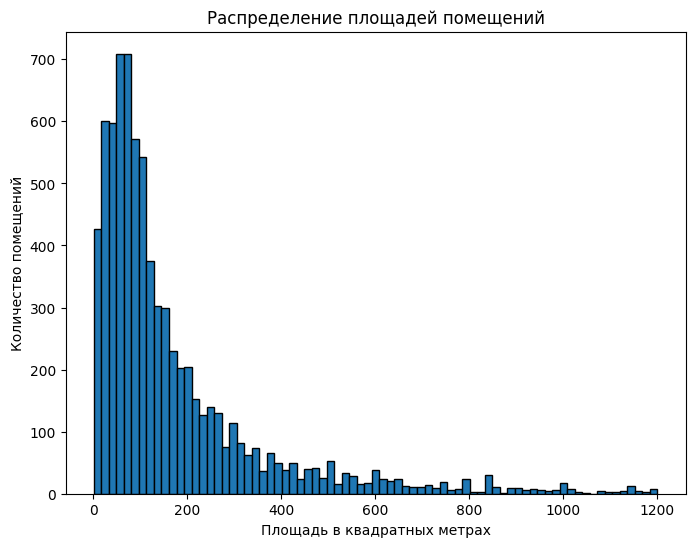

In [ ]:
figsize(8, 6)

plt.hist(df_rent['square, m^2'], bins = 75, edgecolor='k')

plt.xlabel('Площадь в квадратных метрах')
plt.ylabel('Количество помещений')
plt.title('Распределение площадей помещений')
plt.show()

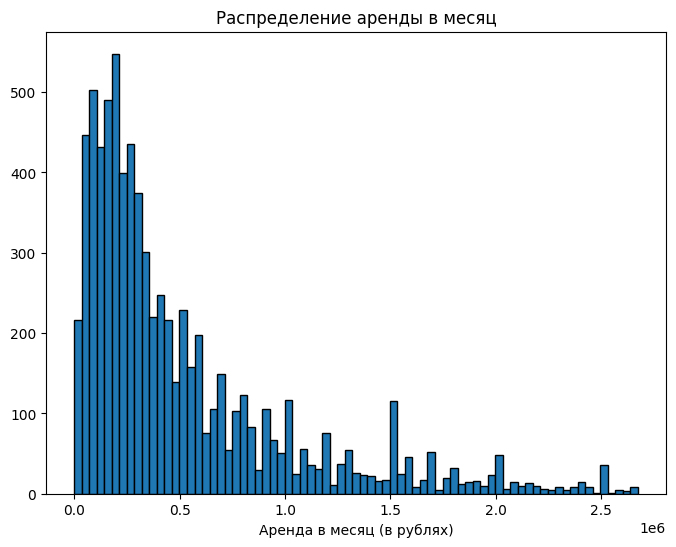

In [ ]:
figsize(8, 6)

plt.hist(df_rent['rent, rub/month'], bins = 75, edgecolor='k')

plt.xlabel('Аренда в месяц (в рублях)')
plt.title('Распределение аренды в месяц')
plt.show()

In [ ]:
import math

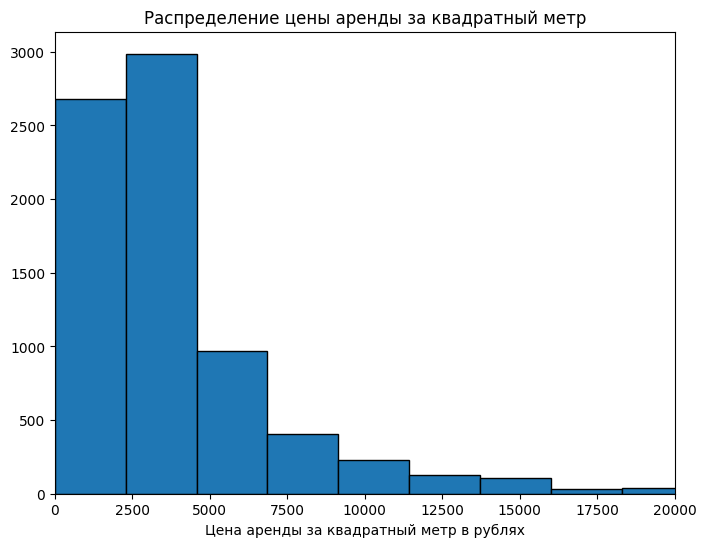

In [ ]:
figsize(8, 6)

plt.hist(df_rent['price_per_sqm, rub/month'], bins = 25, edgecolor='k')
plt.xlim(0, 20000)

plt.xlabel('Цена аренды за квадратный метр в рублях')
plt.title('Распределение цены аренды за квадратный метр')
plt.show()

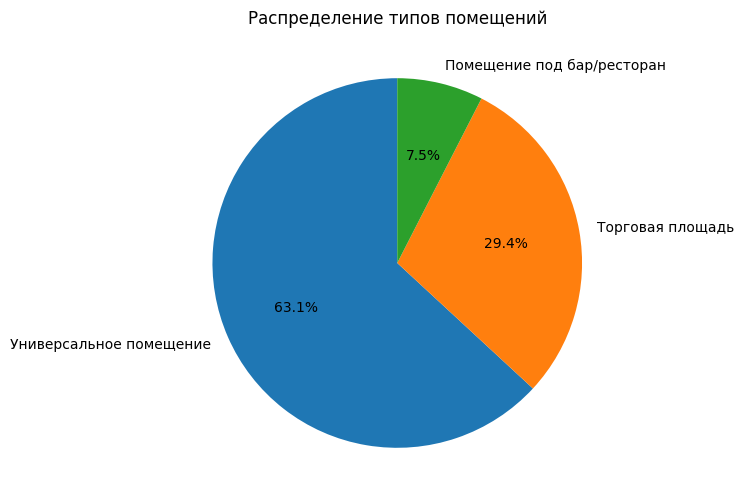

In [ ]:
plt.figure(figsize=(8, 6))

type_counts = df_rent['type'].value_counts()

plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)

plt.title('Распределение типов помещений')
plt.show()

##Univariate analysis - bars

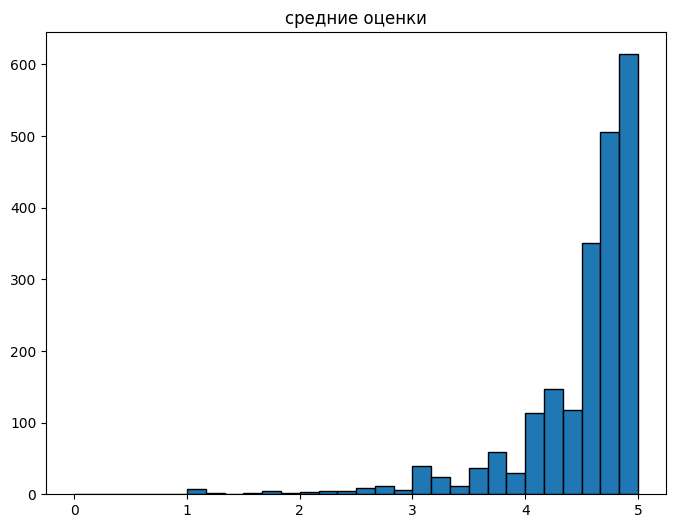

In [ ]:
figsize(8, 6)

plt.hist(df_bars['reviews.general_rating'], bins = 30, edgecolor='k')

plt.title('средние оценки')
plt.show()

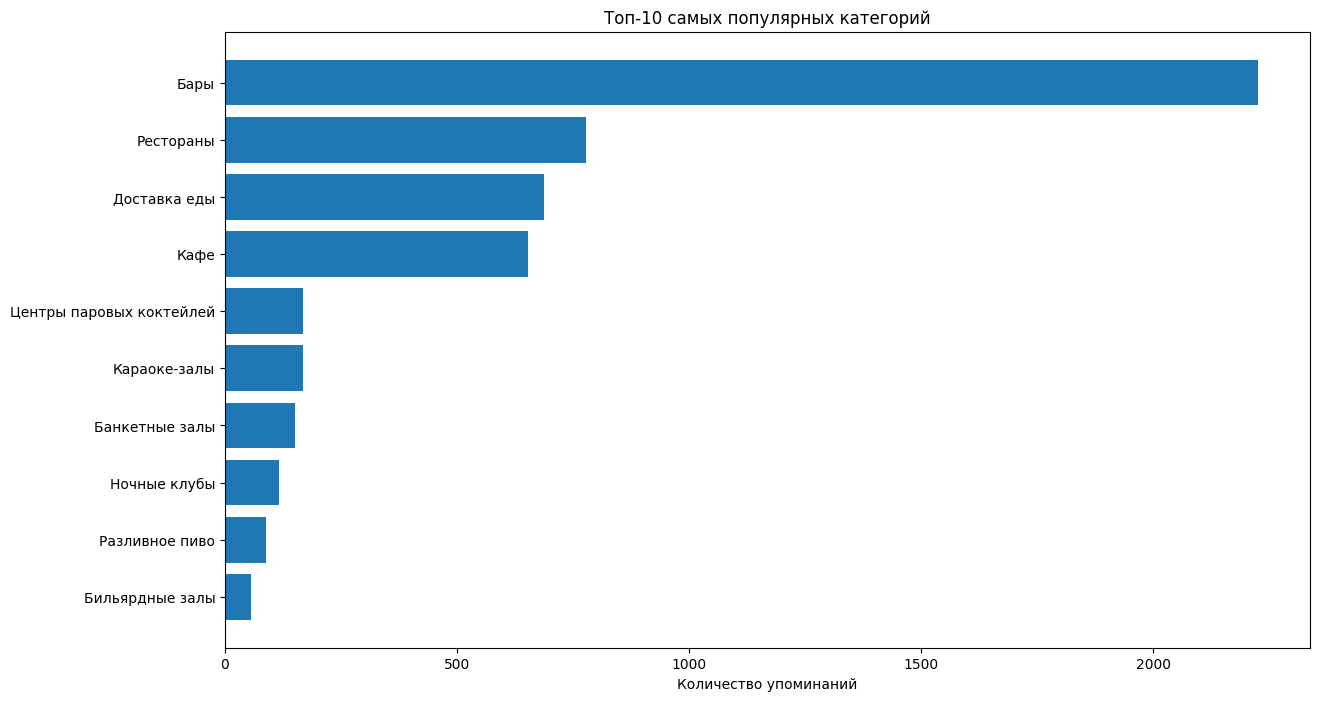

In [ ]:

categories = []
for i in df_bars['rubrics_new'].dropna():
    subcats = [i.strip() for i in i.split(',')]
    categories.extend(subcats)

category_count = {}
for i in categories:
    category_count[i] = category_count.get(i, 0) + 1

top_subcategories = dict(sorted(category_count.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(14, 8))
plt.barh(list(top_subcategories.keys()), list(top_subcategories.values()))
plt.title('Топ-10 самых популярных категорий')
plt.xlabel('Количество упоминаний')
plt.gca().invert_yaxis()
plt.show()

## Multivariate analysis - rent

In [ ]:
df_rent.groupby(['city', 'district']).agg({'rent, rub/month': ['mean', 'median', 'max', 'min'], 'price_per_sqm, rub/month': ['mean', 'median', 'max', 'min']})

rent, rub/month                     \
                                               mean    median      max   
city            district                                                 
Москва          Академический район   456648.420290  320000.0  2367200   
                Алексеевский район    672815.765432  480000.0  2499980   
                Алтуфьевский район    152142.571429  210000.0   260002   
                Бабушкинский район    522533.538462  400000.0  1800000   
                Басманный район       829336.378049  650000.0  2674325   
...                                             ...       ...      ...   
Санкт-Петербург округ № 54            342358.000000  150000.0  1200000   
                округ № 65            271712.240000  175000.0   932400   
                округ № 7             514326.363636  360850.0  1500000   
                округ № 72            129683.000000  146150.0   220000   
                округ № 78            506551.200000  427800.0  1860000   

                                            price_per_sqm, rub/month          \
                                        min                     mean  median   
city            district                                                       
Москва          Академический район   23400              7239.869565  7483.0   
                Алексеевский район    22000              3456.765432  3186.0   
                Алтуфьевский район    35000              2932.000000  2408.0   
                Бабушкинский район    37500              2761.307692  2000.0   
                Басманный район       40000              7293.951220  5019.0   
...                                     ...                      ...     ...   
Санкт-Петербург округ № 54            53438              3408.181818  4128.0   
                округ № 65             2470              1758.080000  1800.0   
                округ № 7             35000              2779.545455  2431.0   
                округ № 72            24998              1530.000000  1630.0   
                округ № 78           151000              3643.350000  2678.5   

                                                  
                                       max   min  
city            district                          
Москва          Академический район  21740  1000  
                Алексеевский район   11250  1077  
                Алтуфьевский район    4000  2000  
                Бабушкинский район    9756   900  
                Басманный район      27778  1400  
...                                    ...   ...  
Санкт-Петербург округ № 54            5106   769  
                округ № 65            4090     9  
                округ № 7             8036  1166  
                округ № 72            2439   850  
                округ № 78           15833  1116  

[218 rows x 8 columns]

In [ ]:
ciry_distr_agg = df_rent.groupby(['city', 'district']).agg({'square, m^2': ['mean'], 'rent, rub/month': ['mean', 'median', 'max', 'min'], 'price_per_sqm, rub/month': ['mean', 'median', 'max', 'min']})

In [ ]:
cities = df_rent['city'].unique()

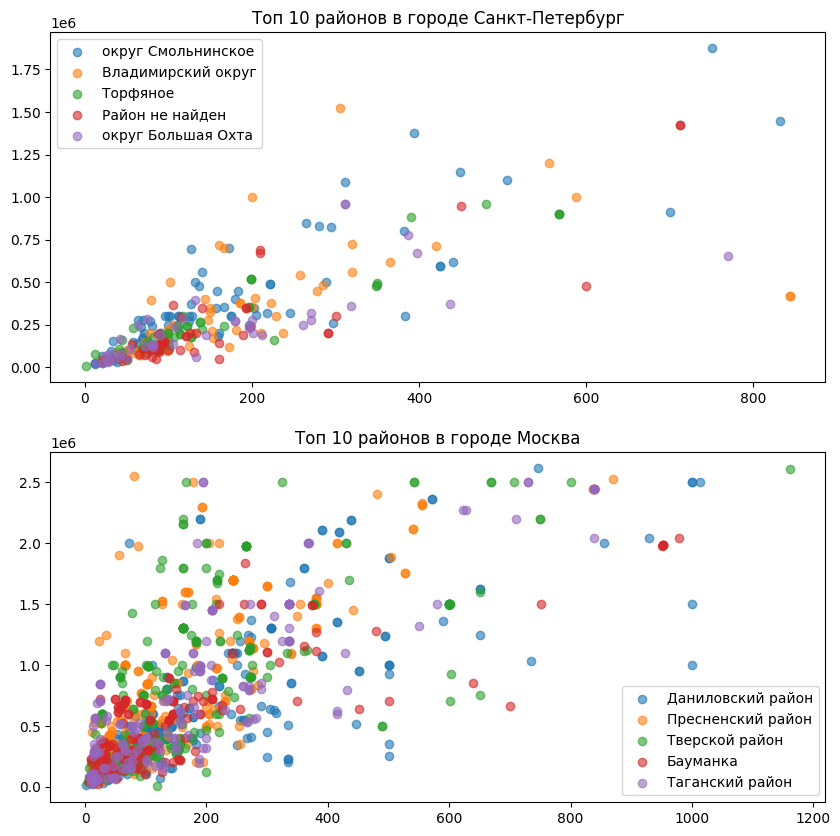

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
axes = axes.flatten()

for i, city in enumerate(cities):
    df_city = df_rent[df_rent['city'] == city]
    top_districts = df_city['district'].value_counts().head(5).index
    print()
    for district in top_districts:
        df_district = df_city[df_city['district'] == district]
        axes[i].scatter(df_district['square, m^2'], df_district['rent, rub/month'], label=district, alpha=0.6)

    axes[i].legend()
    axes[i].set_title(f'Топ 10 районов в городе {city}')

plt.show()

In [ ]:
def new_category(square):
    if square < 50:
        return 'Маленькая'
    elif 50 <= square < 120:
        return 'Средняя'
    elif 120 <= square < 300:
        return 'Большая'
    elif 300 <= square < 600:
        return 'Крупная'
    else:
        return 'Очень крупная'

In [ ]:
df_rent['square_category'] = df_rent['square, m^2'].apply(new_category)

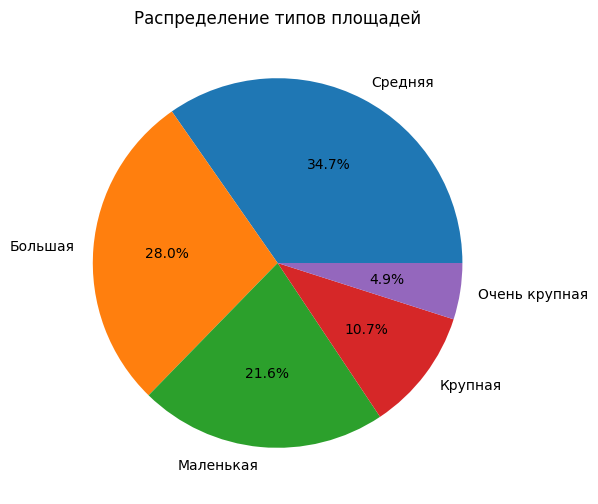

In [ ]:
plt.figure(figsize=(8, 6))

category_counts = df_rent['square_category'].value_counts()

plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')

plt.title('Распределение типов площадей')
plt.show()

In [ ]:
df_rent.groupby(['square_category', 'type']).agg({'rent, rub/month': ['mean', 'count']})

rent, rub/month      
                                                      mean count
square_category type                                            
Большая         Помещение под бар/ресторан    8.063927e+05   184
                Торговая площадь              7.751712e+05   643
                Универсальное помещение       5.785122e+05  1315
Крупная         Помещение под бар/ресторан    1.237640e+06    75
                Торговая площадь              1.187447e+06   186
                Универсальное помещение       9.684465e+05   559
Маленькая       Помещение под бар/ресторан    2.014908e+05    79
                Торговая площадь              2.022631e+05   526
                Универсальное помещение       1.306835e+05  1051
Очень крупная   Помещение под бар/ресторан    1.543765e+06    39
                Торговая площадь              1.549325e+06    82
                Универсальное помещение       1.493853e+06   256
Средняя         Помещение под бар/ресторан    3.414255e+05   199
                Торговая площадь              3.895826e+05   808
                Универсальное помещение       2.716461e+05  1647

In [ ]:
df_rent.groupby(['city', 'square_category']).agg({'rent, rub/month': ['mean', 'count']})

rent, rub/month      
                                           mean count
city            square_category                      
Москва          Большая            7.167471e+05  1765
                Крупная            1.118262e+06   661
                Маленькая          1.710868e+05  1404
                Очень крупная      1.594283e+06   304
                Средняя            3.548874e+05  2040
Санкт-Петербург Большая            3.779744e+05   377
                Крупная            7.287972e+05   159
                Маленькая          7.718534e+04   252
                Очень крупная      1.164602e+06    73
                Средняя            1.728945e+05   614

In [ ]:
global_group = df_rent.groupby(['city', 'square_category', 'type']).agg({'rent, rub/month': ['mean', 'count']})

In [ ]:
city_group = df_rent.groupby('city').agg({'rent, rub/month': ['mean']})

In [ ]:
for i, city in enumerate(df_rent['city'].unique()):
    print('|' * 100)
    print('ГОРОД:')
    print(city.upper())
    print(global_group.loc[city])
    print('-'* 50)
    print(global_group.loc[city, ('rent, rub/month', 'mean')] - city_group.values[i])

||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
ГОРОД:
САНКТ-ПЕТЕРБУРГ
                                           rent, rub/month      
                                                      mean count
square_category type                                            
Большая         Помещение под бар/ресторан    3.764350e+05    39
                Торговая площадь              4.050645e+05    66
                Универсальное помещение       3.716218e+05   272
Крупная         Помещение под бар/ресторан    8.218244e+05    16
                Торговая площадь              8.374593e+05    29
                Универсальное помещение       6.880987e+05   114
Маленькая       Помещение под бар/ресторан    5.156627e+04    11
                Торговая площадь              9.989414e+04    65
                Универсальное помещение       7.039976e+04   176
Очень крупная   Помещение под бар/ресторан    1.305527e+06    11
                Торговая площад

In [ ]:
df_rent.groupby(['city', 'square_category']).agg({'rent, rub/month': ['mean', 'count']}).sort_values(('rent, rub/month', 'mean'))

rent, rub/month      
                                           mean count
city            square_category                      
Санкт-Петербург Маленькая          7.718534e+04   252
Москва          Маленькая          1.710868e+05  1404
Санкт-Петербург Средняя            1.728945e+05   614
Москва          Средняя            3.548874e+05  2040
Санкт-Петербург Большая            3.779744e+05   377
Москва          Большая            7.167471e+05  1765
Санкт-Петербург Крупная            7.287972e+05   159
Москва          Крупная            1.118262e+06   661
Санкт-Петербург Очень крупная      1.164602e+06    73
Москва          Очень крупная      1.594283e+06   304

вывод: очень крупные в бюджет не вписываются, НАХУЙ!!

In [ ]:
df_rent.columns

Index(['rent, rub/month', 'address', 'city', 'price_per_sqm, rub/month',
       'square, m^2', 'type', 'url', 'OSM_address', 'address_info', 'district',
       'lat', 'lon', 'nearest_metro', 'distance_km', 'distance_center_km',
       'distance_center_m', 'square_category'],
      dtype='object')

кодирование

In [ ]:
df_rent['square_category'].unique()

array(['Средняя', 'Маленькая', 'Большая', 'Крупная', 'Очень крупная'],
      dtype=object)

In [ ]:
label_enconding = {'Маленькая': 1, 'Средняя': 2, 'Большая': 3, 'Крупная': 4, 'Очень крупная': 5}

df_rent['square_category_encoding'] = df_rent['square_category'].map(label_enconding)

<Axes: >

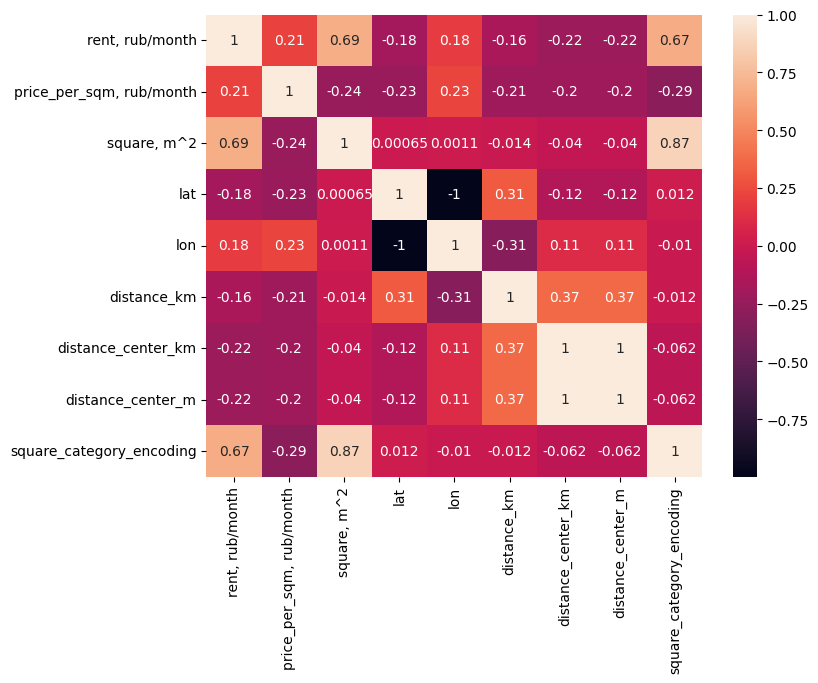

In [ ]:
sns.heatmap(df_rent.corr(numeric_only = True), annot=True)

In [ ]:
df_rent.columns

Index(['rent, rub/month', 'address', 'city', 'price_per_sqm, rub/month',
       'square, m^2', 'type', 'url', 'OSM_address', 'address_info', 'district',
       'lat', 'lon', 'nearest_metro', 'distance_km', 'distance_center_km',
       'distance_center_m', 'square_category', 'square_category_encoding'],
      dtype='object')

In [ ]:
df_rent['address'].sample(10)

,address
2264,Краснопрудная
4704,Генерала Дорохова
4215,Зои и Александра Космодемьянских
3986,Речников
1663,Тестовская
5532,Вернадского проспект
3782,Каширское шоссе
7129,Пятницкое шоссе
2121,Корабельная
6239,Можайское шоссе


## Multivariate analysis - bars

In [ ]:
df_bars

,address_name,name,attributes,address.postcode,point.lat,point.lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new
0,"деревня Сосенки, 150","New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды"
1,"Куприна проспект, 18 к2","Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары
2,"улица Эдварда Грига, 15","Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные"
3,"Скандинавский бульвар, 19","Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей"
4,"Скандинавский бульвар, 12","The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,"улица Фёдора Абрамова, 8а","Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары
2233,"улица Фёдора Абрамова, 8","Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды"
2234,"Ручьёвский проспект, 5","Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары
2235,"Ручьёвский проспект, 15","У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары


In [ ]:
df_bars = df_bars.rename(columns={'point.lat': 'lat', 'point.lon': 'lon'})

In [ ]:
site_lat = df_bars.lat # широта
site_lon = df_bars.lon # долгота
bars_name = df_bars.name

In [ ]:
df_rent['city'].unique()

array(['Санкт-Петербург', 'Москва'], dtype=object)

In [ ]:
cities = df_rent['city'].unique()

for city in cities:
    df_city = df_bars[df_bars['city'] == city]

    data = [go.Scattermapbox(
        lat=site_lat, #широта
        lon=site_lon, #долгота
        mode='markers', #отображаем точки
        marker=dict(
            size=10,
            color='rgb(255, 125, 0)',
            opacity=0.5 #полупрозрачность
        ),
        text=bars_name,
        hoverinfo='text', #только текст при наведении
        )
    ]

    city_centers = {
            'Москва': (55.7558, 37.6173),
            'Санкт-Петербург': (59.9343, 30.3351),
        }
    center_lat, center_lon = city_centers.get(city, (55.0, 37.0))

    layout = go.Layout(
        title=f'Карта баров в городе: {city}',
        autosize=True, #автоматический размер карты
        showlegend=False,
        mapbox=dict(
            style="open-street-map",
            bearing=0, #поворот карты
            center=dict(
                lat=center_lat,
                lon=center_lon
            ),
            pitch=0, #наклон карты
            zoom=10,
        ),
    )

    fig = go.Figure(data=data, layout=layout)

    fig.show()

## Merge

In [ ]:
df_bars

,address_name,name,attributes,address.postcode,lat,lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new
0,"деревня Сосенки, 150","New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды"
1,"Куприна проспект, 18 к2","Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары
2,"улица Эдварда Грига, 15","Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные"
3,"Скандинавский бульвар, 19","Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей"
4,"Скандинавский бульвар, 12","The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,"улица Фёдора Абрамова, 8а","Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары
2233,"улица Фёдора Абрамова, 8","Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды"
2234,"Ручьёвский проспект, 5","Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары
2235,"Ручьёвский проспект, 15","У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары


In [ ]:
df_bars['address_name'] = df_bars['address_name'].str.split(',').str[0]

In [ ]:
df_bars = df_bars.rename(columns={'address_name': 'address'})

In [ ]:
df_bars

,address,name,attributes,address.postcode,lat,lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new
0,деревня Сосенки,"New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды"
1,Куприна проспект,"Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары
2,улица Эдварда Грига,"Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные"
3,Скандинавский бульвар,"Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей"
4,Скандинавский бульвар,"The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,улица Фёдора Абрамова,"Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары
2233,улица Фёдора Абрамова,"Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды"
2234,Ручьёвский проспект,"Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары
2235,Ручьёвский проспект,"У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары


In [ ]:
df_bars_merge = df_bars.merge(df_rent[['address', 'city', 'district']].drop_duplicates(), on=['address', 'city'], how='left')

In [ ]:
df_bars_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   address                                  3055 non-null   object 
 1   name                                     3055 non-null   object 
 2   attributes                               1724 non-null   float64
 3   address.postcode                         3054 non-null   float64
 4   lat                                      3055 non-null   float64
 5   lon                                      3055 non-null   float64
 6   reviews.general_rating                   2887 non-null   float64
 7   reviews.general_review_count             2864 non-null   float64
 8   reviews.general_review_count_with_stars  2919 non-null   float64
 9   reviews.is_reviewable                    3055 non-null   bool   
 10  reviews.is_reviewable_on_flamp           3055 no

In [ ]:
df_bars_merge

,address,name,attributes,address.postcode,lat,lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new,district
0,деревня Сосенки,"New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды",NaN
1,Куприна проспект,"Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары,NaN
2,улица Эдварда Грига,"Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные",NaN
3,Скандинавский бульвар,"Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей",NaN
4,Скандинавский бульвар,"The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3050,улица Фёдора Абрамова,"Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары,NaN
3051,улица Фёдора Абрамова,"Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды",NaN
3052,Ручьёвский проспект,"Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары,NaN
3053,Ручьёвский проспект,"У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары,NaN


## Дозаполнение

In [ ]:
df_bars_merge['postcode_3'] = df_bars_merge['address.postcode'].astype(str).str[:3]

In [ ]:
df_postcodes = pd.read_csv('postcodes.csv')
df_postcodes = df_postcodes.drop_duplicates()
df_postcodes = df_postcodes.rename(columns={'Город': 'city', 'Район': 'district', 'Индекс': 'postcode_district'})

In [ ]:
df_postcodes

,city,district,postcode_district
0,Москва,район Коммунарка,108
1,Москва,Чернево,125
2,Москва,Гавриково,125
3,Москва,район Северное Бутово,117
4,Москва,Бабушкинский район,129
...,...,...,...
306,Екатеринбург,район Кольцово,623
307,Екатеринбург,район Арамиль,623
308,Екатеринбург,район Широкая Речка,620
309,Екатеринбург,район Верхняя Пышма,623


In [ ]:
df_bars_merge = df_bars_merge.merge(df_postcodes, on=['district', 'city'], how='left')
df_bars_merge['postcode_district'] = df_bars_merge['postcode_district'].astype(str).str[:3]

In [ ]:
def difference_district_problem(df_bars):
    df = df_bars_merge.copy()

    mask = df['postcode_3'] != df['postcode_district']

    df.loc[mask, 'district'] = np.nan

    return df

In [ ]:
df_bars_merge = difference_district_problem(df_bars_merge)

In [ ]:
df_bars_merge = df_bars_merge.drop(columns='postcode_district')

In [ ]:
def fill_districts(df_bars_merge):
    df = df_bars_merge.copy()

    postcodes_nan_set = df[df['district'].isna()]['postcode_3'].unique()

    for postcode in postcodes_nan_set:
        bars_available = df[(df['postcode_3'] == postcode) & (df['district'].notna())]
        bars_nan = df[(df['postcode_3'] == postcode) & (df['district'].isna())]

        if len(bars_available) == 0:
            continue

        for i, bar in bars_nan.iterrows():
            distance = np.sqrt((bars_available['lat'] - bar['lat']) ** 2 + (bars_available['lon'] - bar['lon']) ** 2)

            near_index = distance.idxmin()
            near_district = df.loc[near_index, 'district']
            df.loc[i, 'district'] = near_district

    return df

In [ ]:
df_bars_merge = fill_districts(df_bars_merge)

In [ ]:
df_bars_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   address                                  3055 non-null   object 
 1   name                                     3055 non-null   object 
 2   attributes                               1724 non-null   float64
 3   address.postcode                         3054 non-null   float64
 4   lat                                      3055 non-null   float64
 5   lon                                      3055 non-null   float64
 6   reviews.general_rating                   2887 non-null   float64
 7   reviews.general_review_count             2864 non-null   float64
 8   reviews.general_review_count_with_stars  2919 non-null   float64
 9   reviews.is_reviewable                    3055 non-null   bool   
 10  reviews.is_reviewable_on_flamp           3055 no

In [ ]:
df_bars_merge

,address,name,attributes,address.postcode,lat,lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new,district,postcode_3
0,деревня Сосенки,"New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды",NaN,108
1,Куприна проспект,"Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары,NaN,108
2,улица Эдварда Грига,"Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные",NaN,108
3,Скандинавский бульвар,"Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей",NaN,108
4,Скандинавский бульвар,"The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары,NaN,108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3050,улица Фёдора Абрамова,"Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары,округ Светлановское,194
3051,улица Фёдора Абрамова,"Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды",округ Светлановское,194
3052,Ручьёвский проспект,"Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары,NaN,188
3053,Ручьёвский проспект,"У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары,NaN,188


СОХРАНИМ ИТОГ

In [ ]:
df_bars_merge.to_csv('df_bars_merge.csv', index=False)

In [ ]:
df_rent.to_csv('df_rent_final.csv', index=False)

In [ ]:
df = df_bars_merge.copy()

/tmp/ipython-input-1474242497.py:6: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.



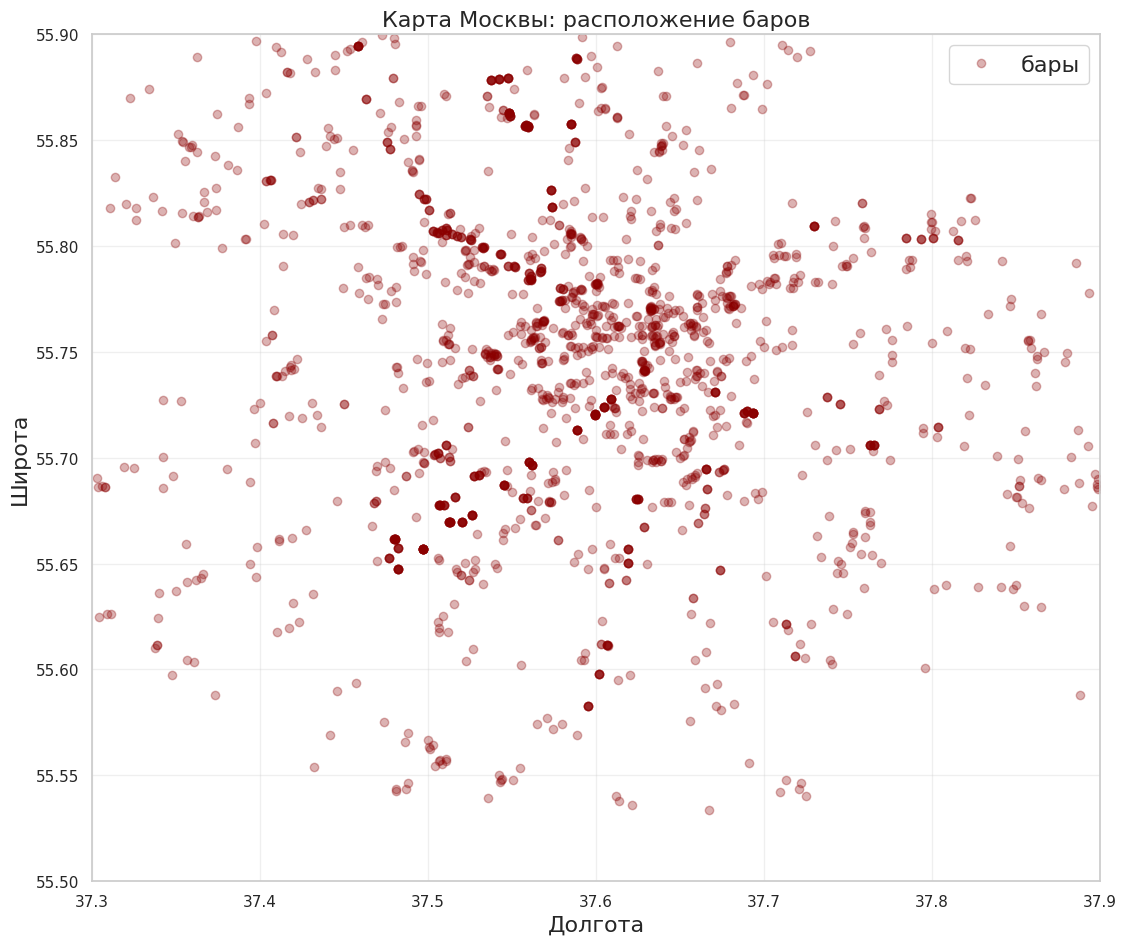

In [ ]:
moscow_data = df[df['city'] == 'Москва']
map_data = moscow_data[(moscow_data['lat'] > 55.5) & (moscow_data['lat'] < 55.9) & (moscow_data['lon'] > 37.3) & (moscow_data['lon'] < 37.9)]

sns.set(style='whitegrid')
plt.figure(figsize=(13, 11))
plt.plot(map_data['lon'], map_data['lat'], 'ro', label='бары', alpha=0.3, color='darkred')
plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Карта Москвы: расположение баров', fontsize=16)
plt.xlim(37.3, 37.9)
plt.ylim(55.5, 55.9)
plt.legend(fontsize=16, frameon=True)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df

,address,name,attributes,address.postcode,lat,lon,reviews.general_rating,reviews.general_review_count,reviews.general_review_count_with_stars,reviews.is_reviewable,reviews.is_reviewable_on_flamp,reviews.items,reviews.org_rating,reviews.org_review_count,reviews.org_review_count_with_stars,address_comment,city,rubrics_new,district,postcode_3
0,деревня Сосенки,"New Moscow, ресторан",NaN,108802.0,55.554086,37.431872,4.9,11.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,11.0,17.0,NaN,Москва,"Бары, Рестораны, Доставка еды",NaN,108
1,Куприна проспект,"Z.a.m.i.n, гастролаундж-бар",NaN,108826.0,55.546534,37.488125,NaN,NaN,NaN,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",NaN,NaN,NaN,NaN,Москва,Бары,NaN,108
2,улица Эдварда Грига,"Слеза комсомолки, рюмочная",NaN,108834.0,55.557202,37.506877,5.0,1.0,2.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",5.0,1.0,2.0,1 этаж,Москва,"Бары, Рюмочные",NaN,108
3,Скандинавский бульвар,"Rich man celebrity, лаундж-бар",NaN,108834.0,55.556860,37.510902,5.0,21.0,23.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.9,50.0,67.0,NaN,Москва,"Бары, Центры паровых коктейлей",NaN,108
4,Скандинавский бульвар,"The Beer, крафтовый бар",NaN,108801.0,55.562626,37.501272,5.0,9.0,17.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,31.0,54.0,NaN,Москва,Бары,NaN,108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3050,улица Фёдора Абрамова,"Abramov, бар",NaN,194363.0,60.073240,30.338235,4.4,8.0,9.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.4,8.0,9.0,1 этаж,Санкт-Петербург,Бары,округ Светлановское,194
3051,улица Фёдора Абрамова,"Pur pur, кафе-бар",1400.0,194363.0,60.072065,30.337600,4.2,53.0,68.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.2,53.0,68.0,NaN,Санкт-Петербург,"Бары, Кафе, Доставка еды",округ Светлановское,194
3052,Ручьёвский проспект,"Crazy, бар",NaN,188677.0,60.065898,30.436743,4.7,25.0,33.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.7,159.0,184.0,NaN,Санкт-Петербург,Бары,NaN,188
3053,Ручьёвский проспект,"У Гриба, бар",NaN,188687.0,60.069321,30.426045,4.8,21.0,34.0,True,True,"[{'is_reviewable': True, 'tag': '2gis_reviews'...",4.8,21.0,34.0,NaN,Санкт-Петербург,Бары,NaN,188


In [ ]:
df1 = df[(df['city'] == 'Москва') & (df['reviews.general_rating'] >= 3.5) & (df['reviews.general_review_count'] >= 10)]

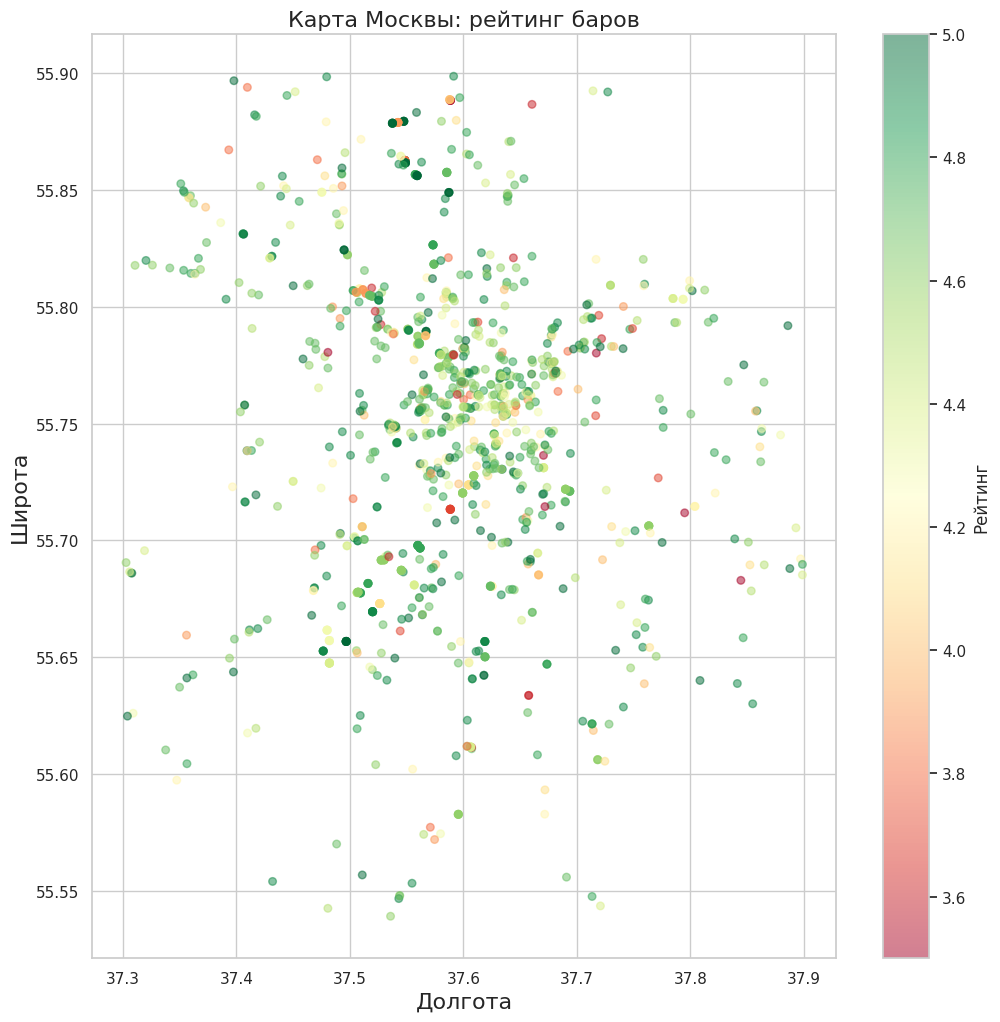

In [ ]:
data = df1[(df1['city'] == 'Москва') & (df1['lat'] > 55.5) & (df1['lat'] < 55.9) & (df1['lon'] > 37.3) & (df1['lon'] < 37.9)]

plt.figure(figsize=(12, 12))
x = data['lon']
y = data['lat']
plt.scatter(x, y, alpha=0.5, c=pd.to_numeric(data['reviews.general_rating']), cmap='RdYlGn', s=30)
plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Карта Москвы: рейтинг баров', fontsize=16)
plt.colorbar(label='Рейтинг')
plt.show()

In [ ]:
df2 = df[(df['city'] == 'Санкт-Петербург') & (df['reviews.general_rating'] >= 3.5) & (df['reviews.general_review_count'] >= 10)]

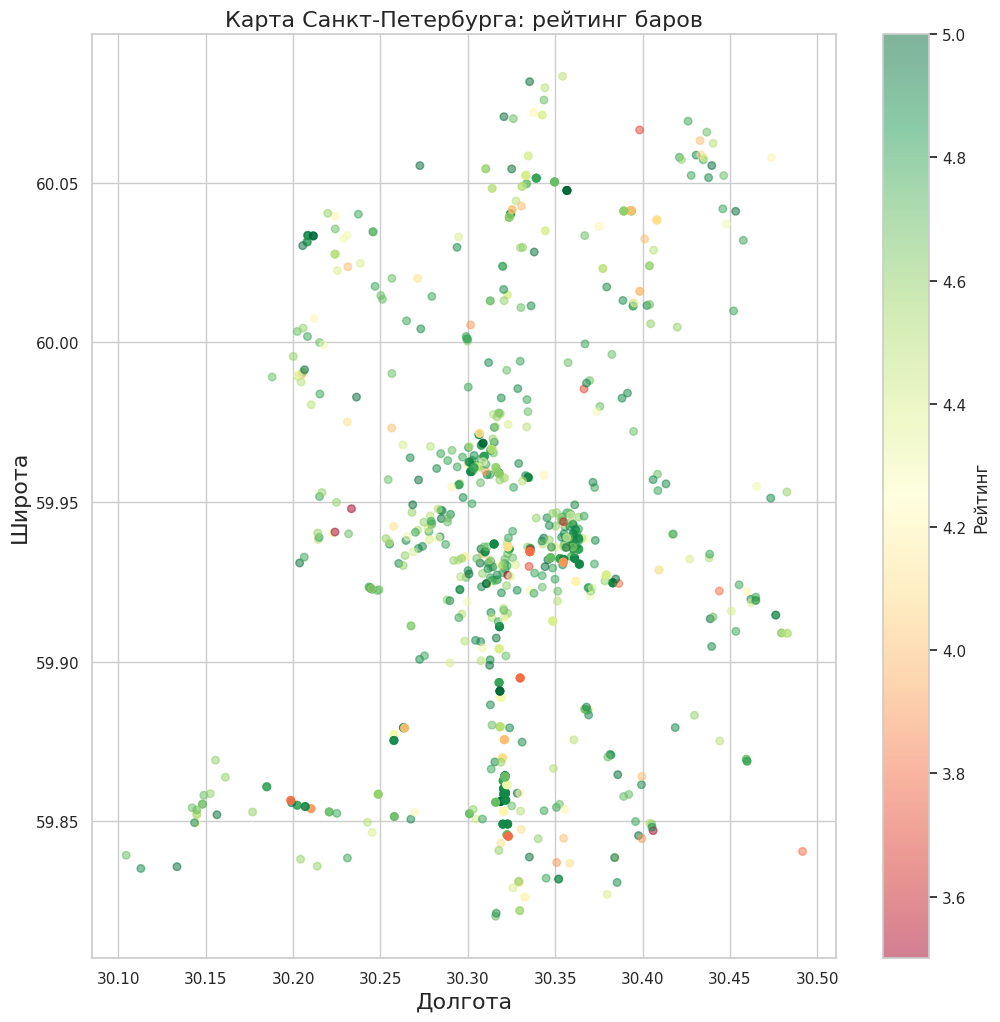

In [ ]:
data = df2[(df2['city'] == 'Санкт-Петербург') & (df2['lat'] > 59.8) & (df2['lat'] < 60.1) & (df2['lon'] > 30.1) & (df2['lon'] < 30.5)]

plt.figure(figsize=(12, 12))
x = data['lon']
y = data['lat']
plt.scatter(x, y, alpha=0.5, c=pd.to_numeric(data['reviews.general_rating']), cmap='RdYlGn', s=30)
plt.xlabel('Долгота', fontsize=16)
plt.ylabel('Широта', fontsize=16)
plt.title('Карта Санкт-Петербурга: рейтинг баров', fontsize=16)
plt.colorbar(label='Рейтинг')
plt.show()

Что берем исходя из гипотез:

-

In [ ]:
df_bars_merge[df_bars_merge['city'] == 'Москва']['attributes'].mean()

np.float64(1940.889110889111)

In [ ]:
df_bars_merge[df_bars_merge['city'] == 'Санкт-Петербург']['attributes'].mean()

np.float64(1483.6652835408022)

In [ ]:
district_rating = df_bars_merge.groupby(['city', 'district', 'postcode_3']).agg({'reviews.general_rating': ['mean', 'count']})

In [ ]:
min_metro = df_rent['distance_km'].mean()

In [ ]:
max_metro = df_rent['distance_km'].mean() + np.quantile(df_rent['distance_km'], 0.6)

In [ ]:
df_rent_spb = df_rent[(df_rent['distance_km'] >= min_metro) &  (df_rent['distance_km'] <= max_metro)]

In [ ]:
Saint_district_rating = district_rating.loc['Санкт-Петербург'].sort_values(by=('reviews.general_rating', 'mean'))

In [ ]:
admi_rating = df_bars_merge.groupby(['city', 'postcode_3']).agg({'reviews.general_rating': ['mean', 'count']}).reset_index()

In [ ]:
admi_rating = admi_rating[admi_rating['postcode_3'] != 'nan']
admi_rating = admi_rating.set_index(['city', 'postcode_3'])

In [ ]:
Saint_admi_rating = admi_rating.loc['Санкт-Петербург'].sort_values(by=('reviews.general_rating', 'mean'))

In [ ]:
Saint_district_rating = Saint_district_rating[(Saint_district_rating[('reviews.general_rating', 'count')] >= 10)]
Saint_district_rating = Saint_district_rating[(Saint_district_rating[('reviews.general_rating', 'count')] >= 15)]

In [ ]:
mean_count_Saint_d = Saint_district_rating[('reviews.general_rating', 'count')].mean()
mean_mean_Saint_d = Saint_district_rating[('reviews.general_rating', 'mean')].mean()
mean_count_Saint_p = Saint_admi_rating[('reviews.general_rating', 'count')].mean()
mean_mean_Saint_p = Saint_admi_rating[('reviews.general_rating', 'mean')].mean()

In [ ]:
Saint_perspective_districts = Saint_district_rating[(Saint_district_rating[('reviews.general_rating', 'count')] <= mean_count_Saint_d) &
                                                      (abs(Saint_district_rating[('reviews.general_rating', 'mean')] - mean_mean_Saint_d) <= 0.2)].reset_index()

In [ ]:
Saint_perspective_admi = Saint_admi_rating[(Saint_admi_rating[('reviews.general_rating', 'count')] <= mean_count_Saint_p) &
                                                      abs((Saint_admi_rating[('reviews.general_rating', 'mean')] - mean_mean_Saint_p) <= 0.2)].reset_index()

In [ ]:
postcodes_perspective = list(set(Saint_perspective_districts['postcode_3']).intersection(set(Saint_perspective_admi['postcode_3'])))

In [ ]:
Saint_perspective_districts_final = Saint_perspective_districts[Saint_perspective_districts['postcode_3'].isin(postcodes_perspective)]

In [ ]:
Saint_perspective_districts_final

district postcode_3 reviews.general_rating      
                                                     mean count
0          Сенной округ        190               4.376000    25
1      округ Малая Охта        195               4.404348    23
4      Балканский округ        192               4.513889    36
6   округ Светлановское        194               4.589189    37
8  Адмиралтейский округ        190               4.700000    34

Санкт-Петербург

In [ ]:
districts_saint = list(Saint_perspective_districts_final['district'].unique())

In [ ]:
df_rent_saint = df_rent_spb[df_rent_spb['district'].isin(Saint_perspective_districts_final['district'])]

1. Помещения под бары/рестораны большая площади

In [ ]:
df_rent_saint_1 = df_rent_saint[df_rent_saint['type'] == 'Помещение под бар/ресторан']

In [ ]:
df_rent_saint_1 = df_rent_saint_1[(df_rent_saint_1['square_category'] == 'Большая') | (df_rent_saint_1['square_category'] == 'Крупная')]

In [ ]:
df_rent_saint_1.sort_values(by=['price_per_sqm, rub/month', 'square, m^2']).head(3)

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km,distance_center_km,distance_center_m,square_category,square_category_encoding
1449,180000,Купчинская,Санкт-Петербург,720,250,Помещение под бар/ресторан,https://spb.n1.ru/view/114306588/?open_card_kn,"Купчинская, 15 корп. 1, Санкт-Петербург, Россия","{'district': 'Балканский округ', 'lat': 59.826...",Балканский округ,59.826238,30.397396,"Санкт-Петербург, Купчино",1.289557,13.36,13360,Большая,3
1428,663100,Олеко Дундича,Санкт-Петербург,1900,349,Помещение под бар/ресторан,https://spb.n1.ru/view/113644003/?open_card_kn,"Олеко Дундича, 36 корп. 1, Санкт-Петербург, Ро...","{'district': 'Балканский округ', 'lat': 59.828...",Балканский округ,59.828210,30.392887,"Санкт-Петербург, Купчино",0.990578,13.06,13060,Крупная,4


2. Универсальное помещение большой площади

In [ ]:
df_rent_saint_2 = df_rent_saint[df_rent_saint['type'] == 'Универсальное помещение']

In [ ]:
df_rent_saint_2 = df_rent_saint_2[(df_rent_saint_2['square_category'] == 'Большая') | (df_rent_saint_2['square_category'] == 'Крупная')]

In [ ]:
df_rent_saint_2.sort_values(by=['price_per_sqm, rub/month', 'square, m^2']).head(3)

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km,distance_center_km,distance_center_m,square_category,square_category_encoding
860,180000,Купчинская,Санкт-Петербург,720,250,Универсальное помещение,https://spb.n1.ru/view/114306588/?open_card_kn,"Купчинская, 15 корп. 1, Санкт-Петербург, Россия","{'district': 'Балканский округ', 'lat': 59.826...",Балканский округ,59.826238,30.397396,"Санкт-Петербург, Купчино",1.289557,13.36,13360,Большая,3
886,350000,Купчинская,Санкт-Петербург,1000,350,Универсальное помещение,https://spb.n1.ru/view/116063250/?open_card_kn,"Купчинская, 32 корп. 1д, Санкт-Петербург, Россия","{'district': 'Балканский округ', 'lat': 59.826...",Балканский округ,59.826238,30.397396,"Санкт-Петербург, Купчино",1.289557,13.36,13360,Крупная,4
658,483000,Купчинская,Санкт-Петербург,1050,460,Универсальное помещение,https://spb.n1.ru/view/116103885/?open_card_kn,"Купчинская, 26 корп. 1, Санкт-Петербург, Россия","{'district': 'Балканский округ', 'lat': 59.824...",Балканский округ,59.824525,30.396711,"Санкт-Петербург, Купчино",1.326323,13.52,13520,Крупная,4


3. Торговая площадь большой площади

In [ ]:
df_rent_saint_3 = df_rent_saint[df_rent_saint['type'] == 'Торговая площадь']

In [ ]:
df_rent_saint_3 = df_rent_saint_3[(df_rent_saint_3['square_category'] == 'Большая') | (df_rent_saint_3['square_category'] == 'Крупная')]

In [ ]:
df_rent_saint_3.sort_values(by=['price_per_sqm, rub/month', 'square, m^2']).head(3)

,"rent, rub/month",address,city,"price_per_sqm, rub/month","square, m^2",type,url,OSM_address,address_info,district,lat,lon,nearest_metro,distance_km,distance_center_km,distance_center_m,square_category,square_category_encoding
1294,300000,Купчинская,Санкт-Петербург,1000,300,Торговая площадь,https://spb.n1.ru/view/115748410/?open_card_kn,"Купчинская, 15 корп. 1, Санкт-Петербург, Россия","{'district': 'Балканский округ', 'lat': 59.826...",Балканский округ,59.826238,30.397396,"Санкт-Петербург, Купчино",1.289557,13.36,13360,Крупная,4
1300,190000,Почтамтская,Санкт-Петербург,1137,167,Торговая площадь,https://spb.n1.ru/view/112819554/?open_card_kn,"Почтамтская, 12, Санкт-Петербург, Россия","{'district': 'Адмиралтейский округ', 'lat': 59...",Адмиралтейский округ,59.931995,30.302462,"Санкт-Петербург, Адмиралтейская",0.817968,0.70,700,Большая,3
1268,750000,Институтский проспект,Санкт-Петербург,1353,554,Торговая площадь,https://spb.n1.ru/view/110570996/?open_card_kn,"Институтский проспект, 3 корп. 1, Санкт-Петерб...","{'district': 'округ Светлановское', 'lat': 60....",округ Светлановское,60.005260,30.351816,"Санкт-Петербург, Площадь Мужества",1.032172,7.93,7930,Крупная,4
